# Strategic correlated-feature pruning

Notebook non execute. Objectif: comparer plusieurs strategies de suppression de features correlees apres retrait des features `overlap`, puis mesurer:

- combien de features restent au total et par famille (`syn`, `cls`, `tda`)
- quelles features sont gardees / supprimees
- si les features restantes passent des tests d'independance approximatifs
- le F1 rapide obtenu avec chaque sous-ensemble
- une heatmap globale unique des correlations Spearman, coloree par famille
- un graphe interactif par methode: noeuds = features, liens = correlations retenues par la methode

Important: ce notebook est genere sans execution. Lance les cellules seulement quand tu veux consommer du calcul.

## 0. Configuration

`FAST_MODE=True` limite les donnees pour tester vite. Pour une decision finale, passer `FAST_MODE=False`.

In [54]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler

try:
    import networkx as nx
    import plotly.graph_objects as go
    HAS_INTERACTIVE_GRAPH = True
except Exception:
    nx = None
    go = None
    HAS_INTERACTIVE_GRAPH = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    XGBClassifier = None
    HAS_XGBOOST = False

warnings.filterwarnings('ignore')

REPO = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
OUTPUT_ROOT = REPO / 'outputs' / 'exp_occidata'
FOLDS_ROOT = OUTPUT_ROOT / 'folds'
REPORT_DIR = OUTPUT_ROOT / 'reports' / 'meeting_baselines_vs_metamatch' / 'feature_correlation_strategic_pruning'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

FAST_MODE = True
SEED = 42
DROP_OVERLAP = True
DROP_CONSTANT = True

if FAST_MODE:
    SAMPLE_PER_FOLD = 5_000
    EVAL_SAMPLE_PER_FOLD = 20_000
    N_ESTIMATORS = 80
else:
    SAMPLE_PER_FOLD = 0
    EVAL_SAMPLE_PER_FOLD = 0
    N_ESTIMATORS = 220

CORR_THRESHOLDS = [0.5, 0.55,0.60,0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
NMI_THRESHOLDS = [0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
VIF_THRESHOLDS = [5.0, 10.0, 20.0, 50.0]
INDEPENDENCE_ALPHA = 0.05

print('Notebook ready. No computation has happened before running this cell manually.')

Notebook ready. No computation has happened before running this cell manually.


## 1. Chargement des folds et suppression des overlap

Cette section charge les folds existants et retire les features contenant `overlap`.

In [55]:
def build_eval_model(y_train, seed):
    if HAS_XGBOOST:
        n_pos = max(1, int(y_train.sum()))
        n_neg = max(1, int(len(y_train) - y_train.sum()))
        return XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=seed,
            n_jobs=1,
            scale_pos_weight=n_neg / n_pos,
        )

    return LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=seed,
    )


def dataset_group_column(df):
    if "pair_id" not in df.columns:
        raise KeyError("Expected pair_id column for table-pair evaluation")
    return "pair_id"


def evaluate_folds_all2all_opt_train(method, hyperparams, features):
    fold_rows = []
    dataset_rows = []

    for fid in fold_ids:
        train_df = read_fold_table(fid, "train")
        test_df = read_fold_table(fid, "test")

        if EVAL_SAMPLE_PER_FOLD and len(train_df) > EVAL_SAMPLE_PER_FOLD:
            train_df = sample_train_fold(train_df, EVAL_SAMPLE_PER_FOLD, SEED + fid)

        X_train, imp, sc = make_numeric_matrix(train_df[features], scale="robust")
        X_test = sc.transform(imp.transform(test_df[features])) if sc is not None else imp.transform(test_df[features])

        y_train = train_df["label"].astype(int).to_numpy()
        y_test = test_df["label"].astype(int).to_numpy()

        model = build_eval_model(y_train, SEED + fid)
        model.fit(X_train, y_train)

        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]

        thr = best_threshold(y_train, train_score)
        pred = (test_score >= thr).astype(int)

        fold_rows.append({
            "method": method,
            "hyperparams": json.dumps(hyperparams, sort_keys=True),
            "fold_id": fid,
            "n_features": len(features),
            "threshold_opt_train": thr,
            "precision_all2all_opt_train": float(precision_score(y_test, pred, zero_division=0)),
            "recall_all2all_opt_train": float(recall_score(y_test, pred, zero_division=0)),
            "f1_all2all_opt_train": float(f1_score(y_test, pred, zero_division=0)),
            "features": " | ".join(features),
        })

        group_col = dataset_group_column(test_df)
        if group_col is not None:
            tmp = test_df[[group_col, "label"]].copy()
            tmp["pred"] = pred

            for dataset_name, part in tmp.groupby(group_col):
                if part["label"].nunique() < 2:
                    continue

                dataset_rows.append({
                    "method": method,
                    "hyperparams": json.dumps(hyperparams, sort_keys=True),
                    "fold_id": fid,
                    "dataset": dataset_name,
                    "n_rows": len(part),
                    "n_pos": int(part["label"].sum()),
                    "f1_dataset_opt_train": float(
                        f1_score(part["label"], part["pred"], zero_division=0)
                    ),
                })

    fold_eval = pd.DataFrame(fold_rows)
    dataset_eval = pd.DataFrame(dataset_rows)

    summary = {
        "mean_precision_folds": float(fold_eval["precision_all2all_opt_train"].mean()) if not fold_eval.empty else np.nan,
        "std_precision_folds": float(fold_eval["precision_all2all_opt_train"].std()) if len(fold_eval) > 1 else np.nan,
        "mean_recall_folds": float(fold_eval["recall_all2all_opt_train"].mean()) if not fold_eval.empty else np.nan,
        "std_recall_folds": float(fold_eval["recall_all2all_opt_train"].std()) if len(fold_eval) > 1 else np.nan,
        "mean_f1_folds": float(fold_eval["f1_all2all_opt_train"].mean()) if not fold_eval.empty else np.nan,
        "std_f1_folds": float(fold_eval["f1_all2all_opt_train"].std()) if len(fold_eval) > 1 else np.nan,
        "mean_precision_pairs": float(dataset_eval["precision_pair_opt_train"].mean()) if not dataset_eval.empty else np.nan,
        "std_precision_pairs": float(dataset_eval["precision_pair_opt_train"].std()) if len(dataset_eval) > 1 else np.nan,
        "mean_recall_pairs": float(dataset_eval["recall_pair_opt_train"].mean()) if not dataset_eval.empty else np.nan,
        "std_recall_pairs": float(dataset_eval["recall_pair_opt_train"].std()) if len(dataset_eval) > 1 else np.nan,
        "mean_f1_pairs": float(dataset_eval["f1_pair_opt_train"].mean()) if not dataset_eval.empty else np.nan,
        "std_f1_pairs": float(dataset_eval["f1_pair_opt_train"].std()) if len(dataset_eval) > 1 else np.nan,
        "n_pair_ids_eval": int(dataset_eval["dataset"].nunique()) if not dataset_eval.empty else 0,
    }

    return fold_eval, dataset_eval, summary

In [56]:
def read_fold_table(fold_id, split):
    folder = FOLDS_ROOT / f'fold_{fold_id}'
    for suffix in ['parquet', 'csv.gz', 'csv']:
        path = folder / f'{split}.{suffix}'
        if path.exists():
            if suffix == 'parquet':
                return pd.read_parquet(path)
            return pd.read_csv(path)
    raise FileNotFoundError(f'Missing {split} file for fold {fold_id}')

def feature_family(feature):
    return feature.split('_', 1)[0]

def get_feature_columns(df):
    cols = [c for c in df.columns if c.startswith(('syn_', 'cls_', 'tda_'))]
    if DROP_OVERLAP:
        cols = [c for c in cols if 'overlap' not in c.lower()]
    if DROP_CONSTANT:
        nunique = df[cols].nunique(dropna=False)
        cols = [c for c in cols if nunique[c] > 1]
    return cols

def sample_train_fold(df, sample_n, seed):
    if sample_n == 0 or len(df) <= sample_n:
        return df.copy()
    pos = df[df['label'] == 1]
    neg = df[df['label'] == 0]
    n_pos = min(len(pos), max(1, sample_n // 3))
    n_neg = sample_n - n_pos
    pos_s = pos.sample(n=n_pos, random_state=seed, replace=len(pos) < n_pos)
    neg_s = neg.sample(n=min(n_neg, len(neg)), random_state=seed)
    return pd.concat([pos_s, neg_s], ignore_index=True).sample(frac=1.0, random_state=seed)

fold_ids = sorted(int(p.name.split('_')[-1]) for p in FOLDS_ROOT.glob('fold_*'))
fold0 = read_fold_table(fold_ids[0], 'train')
FEATURES = get_feature_columns(fold0)

sample_parts = []
for fid in fold_ids:
    train_df = read_fold_table(fid, 'train')
    sample_parts.append(sample_train_fold(train_df, SAMPLE_PER_FOLD, SEED + fid))

work_df = pd.concat(sample_parts, ignore_index=True)
X_raw = work_df[FEATURES].copy()
y = work_df['label'].astype(int).to_numpy()

feature_overview = pd.DataFrame({'feature': FEATURES, 'family': [feature_family(f) for f in FEATURES]})
display(feature_overview.groupby('family').size().rename('n_features').reset_index())
print('Total candidate features after overlap removal:', len(FEATURES))

,family,n_features
0,cls,8
1,syn,19
2,tda,31


Total candidate features after overlap removal: 58


## 2. Helpers communs

Ces fonctions sont reutilisees par toutes les methodes: preprocessing, relevance au target, tests d'independance, graphes et F1 rapide.

,feature,family,mi_target
0,syn_jaro_winkler,syn,0.348813
1,syn_jaro,syn,0.347657
2,syn_cosine_bigrams,syn,0.345809
3,syn_cosine_trigrams,syn,0.330726
4,cls_euclidean,cls,0.323570
5,cls_cosine_dist,cls,0.323532
6,cls_cosine_sim,cls,0.323532
7,cls_pearson,cls,0.322977
8,cls_minkowski,cls,0.322902
9,cls_canberra,cls,0.322310


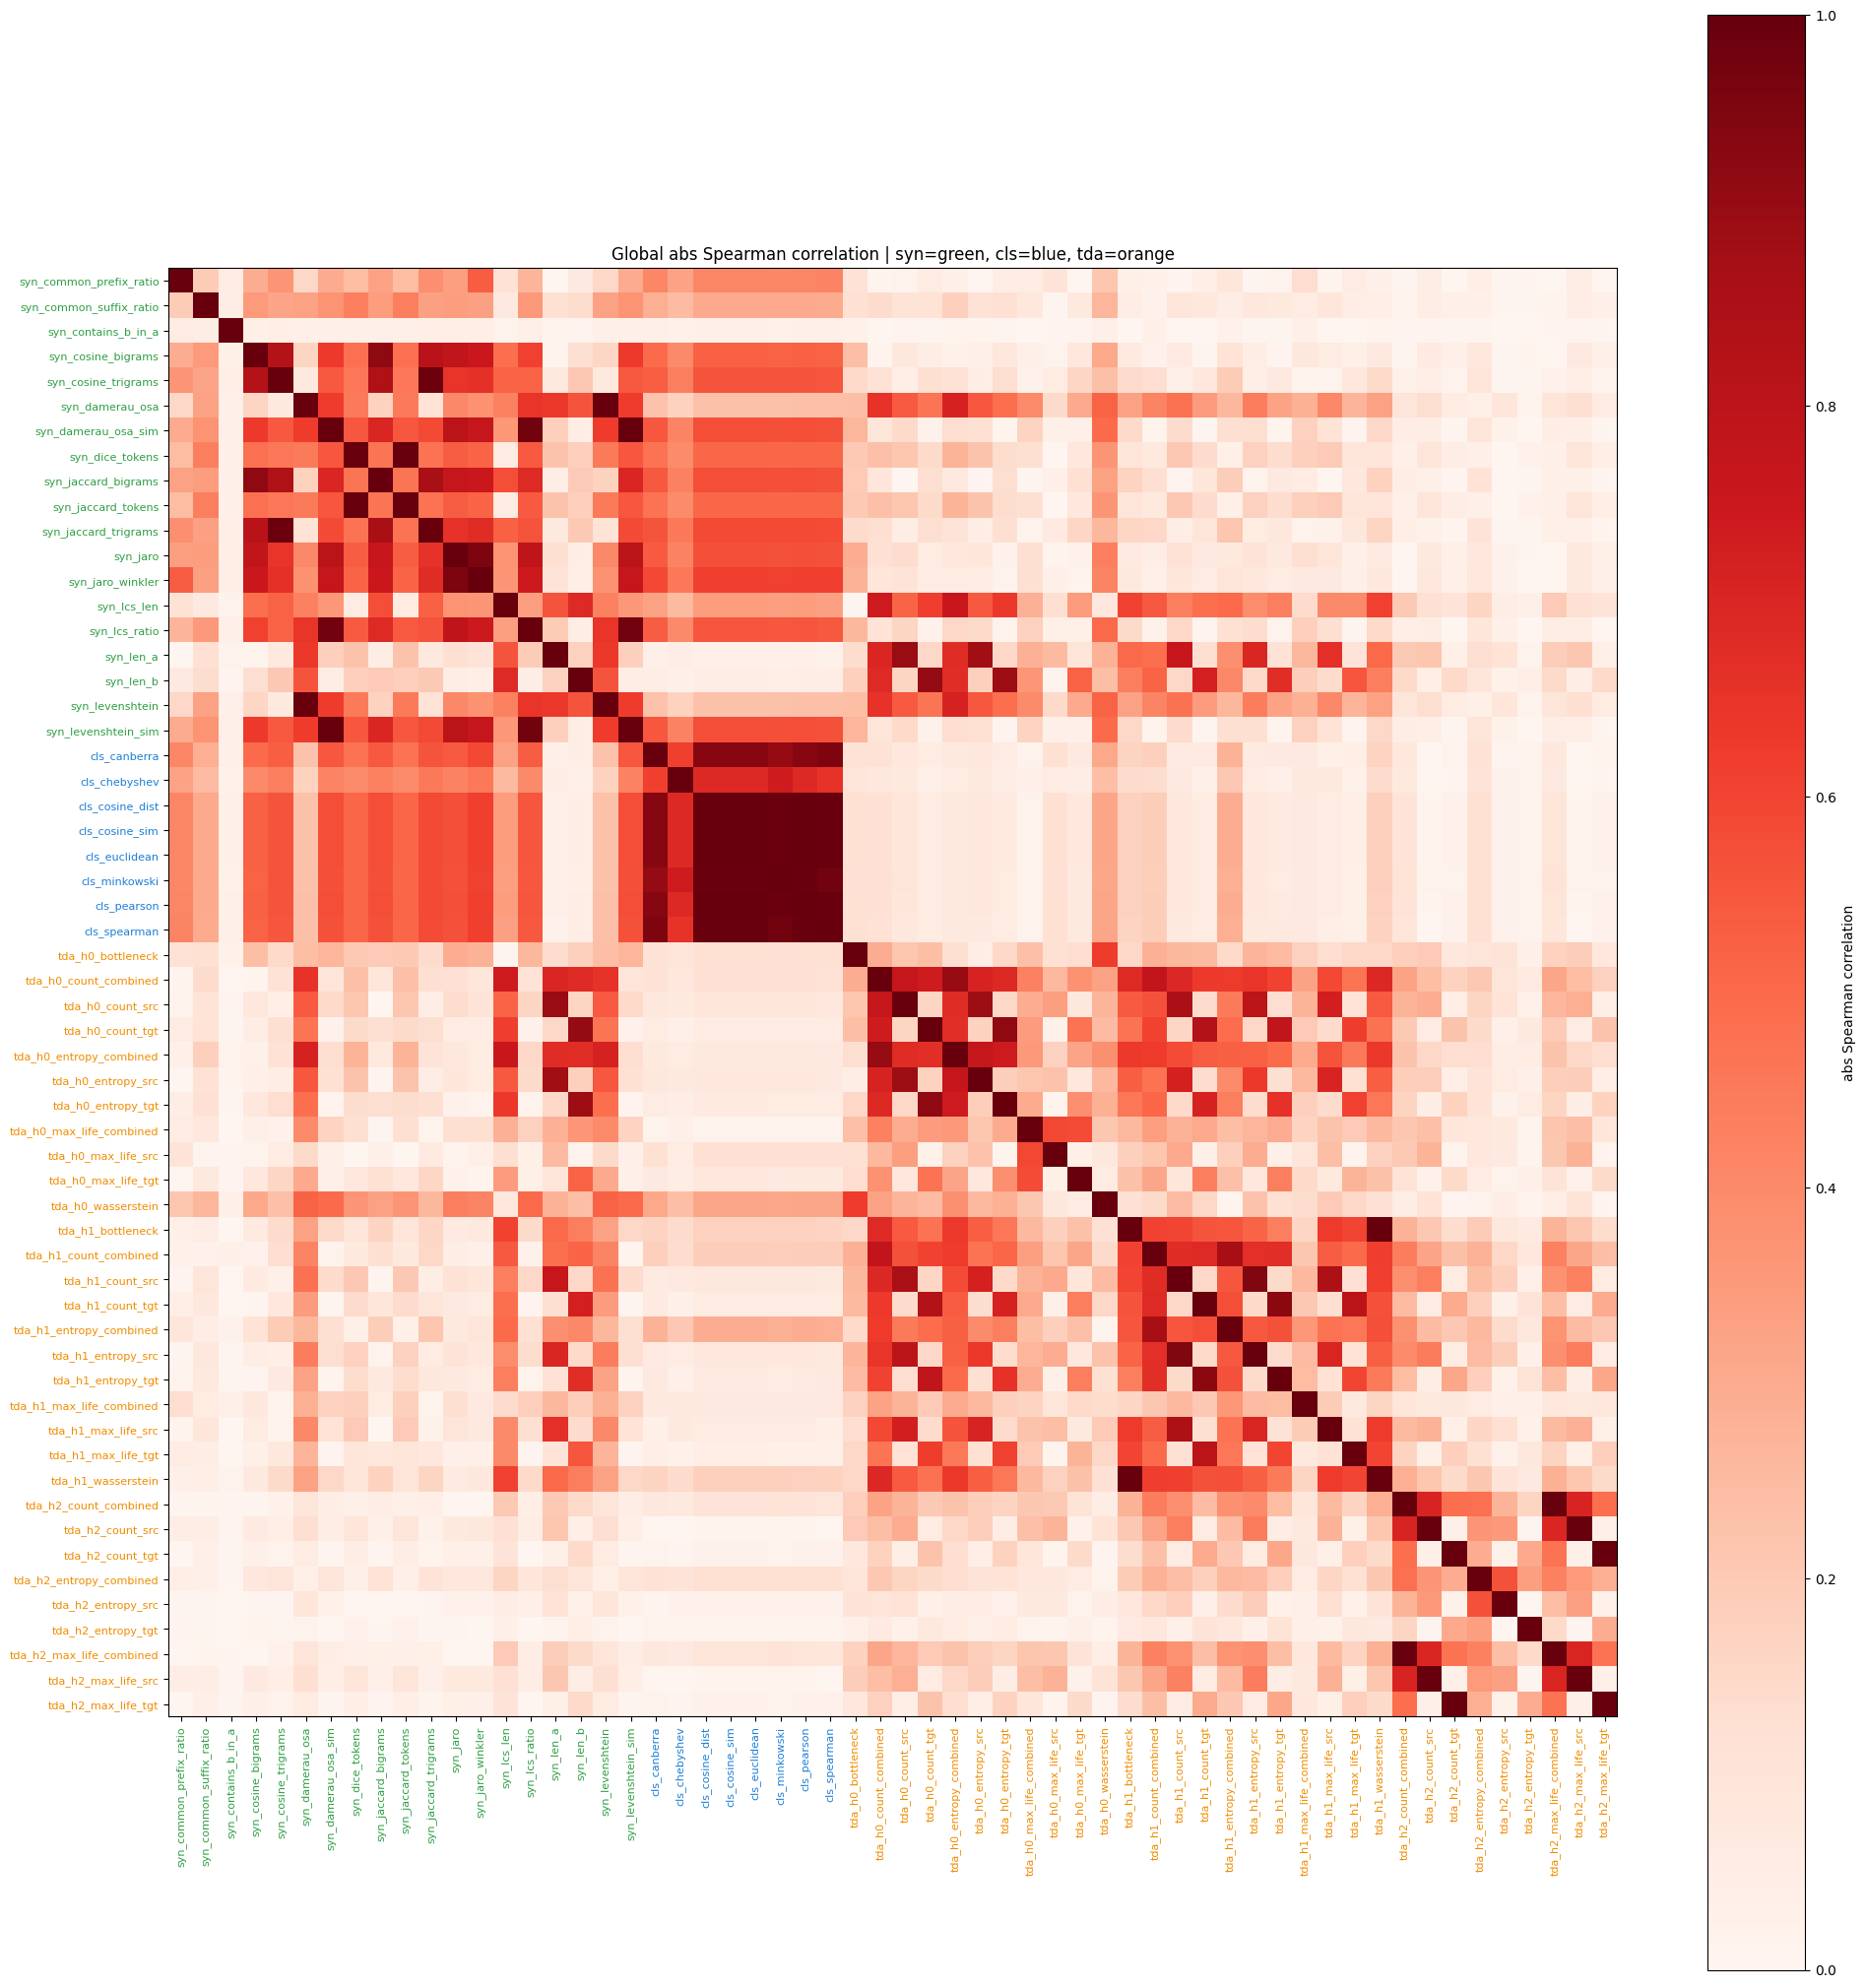

In [57]:
def make_numeric_matrix(X_df, scale='robust'):
    imputer = SimpleImputer(strategy='median')
    X_imp = imputer.fit_transform(X_df)
    if scale == 'robust':
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X_imp)
    elif scale == 'minmax':
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X_imp)
    elif scale is None:
        scaler = None
        X_scaled = X_imp
    else:
        raise ValueError(scale)
    return X_scaled, imputer, scaler

X, imputer, scaler = make_numeric_matrix(X_raw, scale='robust')
feature_names = np.array(FEATURES)

mi_target = mutual_info_classif(X, y, discrete_features=False, random_state=SEED, n_neighbors=3)
relevance_df = pd.DataFrame({
    'feature': feature_names,
    'family': [feature_family(f) for f in feature_names],
    'mi_target': mi_target,
}).sort_values('mi_target', ascending=False).reset_index(drop=True)

spearman_corr = pd.DataFrame(X, columns=feature_names).corr(method='spearman').fillna(0.0)
pearson_corr = pd.DataFrame(X, columns=feature_names).corr(method='pearson').fillna(0.0)
kendall_corr = pd.DataFrame(X, columns=feature_names).corr(method='kendall').fillna(0.0)

display(relevance_df.head(20))

def draw_global_family_correlation_heatmap(corr_df=spearman_corr):
    family_order = {'syn': 0, 'cls': 1, 'tda': 2}
    ordered = sorted(corr_df.columns, key=lambda f: (family_order.get(feature_family(f), 99), f))
    colors = {'syn': '#2f9e44', 'cls': '#1c7ed6', 'tda': '#f08c00'}
    tick_colors = [colors.get(feature_family(f), '#666666') for f in ordered]
    sub = corr_df.loc[ordered, ordered].abs()

    fig, ax = plt.subplots(figsize=(max(9, 0.35 * len(ordered)), max(8, 0.35 * len(ordered))))
    im = ax.imshow(sub, vmin=0, vmax=1, cmap='Reds')
    ax.set_xticks(range(len(ordered)))
    ax.set_yticks(range(len(ordered)))
    ax.set_xticklabels(ordered, rotation=90, fontsize=8)
    ax.set_yticklabels(ordered, fontsize=8)
    for tick, color in zip(ax.get_xticklabels(), tick_colors):
        tick.set_color(color)
    for tick, color in zip(ax.get_yticklabels(), tick_colors):
        tick.set_color(color)
    ax.set_title('Global abs Spearman correlation | syn=green, cls=blue, tda=orange')
    fig.colorbar(im, ax=ax, label='abs Spearman correlation')
    plt.tight_layout()
    plt.show()

draw_global_family_correlation_heatmap()

In [58]:
def summarize_selection(method, hyperparams, selected, all_features=FEATURES):
    selected = list(selected)
    selected_set = set(selected)
    removed = [f for f in all_features if f not in selected_set]
    fam_rows = []
    for fam in ['syn', 'cls', 'tda']:
        before = sum(feature_family(f) == fam for f in all_features)
        after = sum(feature_family(f) == fam for f in selected)
        fam_rows.append({
            'method': method,
            'hyperparams': json.dumps(hyperparams, sort_keys=True),
            'family': fam,
            'before': before,
            'after': after,
            'removed': before - after,
        })
    return {
        'method': method,
        'hyperparams': hyperparams,
        'n_selected': len(selected),
        'n_removed': len(removed),
        'selected': selected,
        'removed': removed,
        'family_stats': pd.DataFrame(fam_rows),
    }

def pairwise_upper_values(corr_df, features):
    if len(features) < 2:
        return np.array([])
    sub = corr_df.loc[features, features].abs().to_numpy()
    return sub[np.triu_indices_from(sub, k=1)]

def benjamini_hochberg(pvalues, alpha=0.05):
    pvalues = np.asarray(pvalues, dtype=float)
    if len(pvalues) == 0:
        return np.array([], dtype=bool), np.array([])
    order = np.argsort(pvalues)
    ranked = pvalues[order]
    thresholds = alpha * (np.arange(1, len(pvalues) + 1) / len(pvalues))
    passed = ranked <= thresholds
    rejected = np.zeros(len(pvalues), dtype=bool)
    if passed.any():
        max_i = np.where(passed)[0].max()
        rejected[order[:max_i + 1]] = True
    q = np.empty(len(pvalues), dtype=float)
    prev = 1.0
    for i in range(len(ranked) - 1, -1, -1):
        val = ranked[i] * len(pvalues) / (i + 1)
        prev = min(prev, val)
        q[order[i]] = min(prev, 1.0)
    return rejected, q

def independence_report(X_df, features, alpha=INDEPENDENCE_ALPHA):
    rows = []
    if len(features) < 2:
        return pd.DataFrame([{'test': 'not_enough_features', 'passed': True, 'detail': '0 or 1 feature'}])

    X_local = X_df[features].copy()
    rho_values = []
    p_values = []
    pairs = []
    for i, a in enumerate(features):
        for b in features[i + 1:]:
            rho, p = stats.spearmanr(X_local[a], X_local[b], nan_policy='omit')
            rho_values.append(abs(0.0 if np.isnan(rho) else rho))
            p_values.append(1.0 if np.isnan(p) else p)
            pairs.append((a, b))

    rejected, q_values = benjamini_hochberg(p_values, alpha=alpha)
    significant_pairs = int(rejected.sum())
    max_abs_rho = float(np.max(rho_values)) if rho_values else 0.0
    median_abs_rho = float(np.median(rho_values)) if rho_values else 0.0

    rows.append({
        'test': 'Spearman pairwise + Benjamini-Hochberg',
        'passed': significant_pairs == 0,
        'detail': f'{significant_pairs}/{len(pairs)} significant pairs at alpha={alpha}',
        'max_abs_dependence': max_abs_rho,
        'median_abs_dependence': median_abs_rho,
    })

    # Chi-square independence on quantile bins. This is approximate for continuous features.
    chi_p = []
    for a, b in pairs:
        try:
            aa = pd.qcut(X_local[a].rank(method='first'), q=5, labels=False, duplicates='drop')
            bb = pd.qcut(X_local[b].rank(method='first'), q=5, labels=False, duplicates='drop')
            table = pd.crosstab(aa, bb)
            if table.shape[0] > 1 and table.shape[1] > 1:
                _, p, _, _ = stats.chi2_contingency(table)
                chi_p.append(p)
        except Exception:
            pass
    chi_rejected, _ = benjamini_hochberg(chi_p, alpha=alpha)
    rows.append({
        'test': 'Binned chi-square + Benjamini-Hochberg',
        'passed': int(chi_rejected.sum()) == 0,
        'detail': f'{int(chi_rejected.sum())}/{len(chi_p)} significant binned pairs at alpha={alpha}',
        'max_abs_dependence': np.nan,
        'median_abs_dependence': np.nan,
    })
    return pd.DataFrame(rows)

def best_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5
    p = precision[1:]
    r = recall[1:]
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    return float(thresholds[int(np.nanargmax(f1))])

def build_eval_model(y_train, seed):
    if HAS_XGBOOST:
        n_pos = max(1, int(y_train.sum()))
        n_neg = max(1, int(len(y_train) - y_train.sum()))
        return XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            random_state=seed,
            n_jobs=1,
            scale_pos_weight=n_neg / n_pos,
        )
    return LogisticRegression(class_weight='balanced', max_iter=1000, random_state=seed)

def dataset_group_column(df):
    for col in ['dataset', 'dataset_name', 'source_dataset', 'category']:
        if col in df.columns:
            return col
    return None

def evaluate_folds_all2all_opt_train(method, hyperparams, features):
    fold_rows = []
    dataset_rows = []
    for fid in fold_ids:
        train_df = read_fold_table(fid, 'train')
        test_df = read_fold_table(fid, 'test')
        if EVAL_SAMPLE_PER_FOLD and len(train_df) > EVAL_SAMPLE_PER_FOLD:
            train_df = sample_train_fold(train_df, EVAL_SAMPLE_PER_FOLD, SEED + fid)

        X_train, imp, sc = make_numeric_matrix(train_df[features], scale='robust')
        X_test = sc.transform(imp.transform(test_df[features])) if sc is not None else imp.transform(test_df[features])
        y_train = train_df['label'].astype(int).to_numpy()
        y_test = test_df['label'].astype(int).to_numpy()

        model = build_eval_model(y_train, SEED + fid)
        model.fit(X_train, y_train)
        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]
        thr = best_threshold(y_train, train_score)
        pred = (test_score >= thr).astype(int)
        fold_f1 = float(f1_score(y_test, pred, zero_division=0))

        fold_rows.append({
            'method': method,
            'hyperparams': json.dumps(hyperparams, sort_keys=True),
            'fold_id': fid,
            'n_features': len(features),
            'threshold_opt_train': thr,
            'f1_all2all_opt_train': fold_f1,
            'features': ' | '.join(features),
        })

        group_col = dataset_group_column(test_df)
        if group_col is not None:
            tmp = test_df[[group_col, 'label']].copy()
            tmp['pred'] = pred
            for dataset_name, part in tmp.groupby(group_col):
                if part['label'].nunique() < 2:
                    continue
                dataset_rows.append({
                    'method': method,
                    'hyperparams': json.dumps(hyperparams, sort_keys=True),
                    'fold_id': fid,
                    'dataset': dataset_name,
                    'n_rows': len(part),
                    'n_pos': int(part['label'].sum()),
                    'f1_dataset_opt_train': float(f1_score(part['label'], part['pred'], zero_division=0)),
                })

    fold_eval = pd.DataFrame(fold_rows)
    dataset_eval = pd.DataFrame(dataset_rows)
    summary = {
        'mean_f1_folds': float(fold_eval['f1_all2all_opt_train'].mean()) if not fold_eval.empty else np.nan,
        'std_f1_folds': float(fold_eval['f1_all2all_opt_train'].std()) if len(fold_eval) > 1 else np.nan,
        'mean_f1_datasets': float(dataset_eval['f1_dataset_opt_train'].mean()) if not dataset_eval.empty else np.nan,
        'std_f1_datasets': float(dataset_eval['f1_dataset_opt_train'].std()) if len(dataset_eval) > 1 else np.nan,
        'n_datasets_eval': int(dataset_eval['dataset'].nunique()) if not dataset_eval.empty else 0,
    }
    return fold_eval, dataset_eval, summary

def draw_correlation_outputs(result, corr_df=None, edge_threshold=0.85):
    method = result['method']
    if corr_df is None:
        if 'pearson' in method:
            corr_df = pearson_corr
            metric_name = 'abs Pearson'
        elif 'kendall' in method:
            corr_df = kendall_corr
            metric_name = 'abs Kendall'
        elif 'nmi' in method and 'nmi_matrix' in globals():
            corr_df = nmi_matrix
            metric_name = 'NMI'
        else:
            corr_df = spearman_corr
            metric_name = 'abs Spearman'
    else:
        metric_name = 'similarity'
    selected = result['selected']
    removed = result['removed']
    selected_set = set(selected)
    ordered = selected + removed
    family_colors = {'syn': '#2f9e44', 'cls': '#1c7ed6', 'tda': '#f08c00'}

    edge_rows = []
    for i, a in enumerate(ordered):
        for b in ordered[i + 1:]:
            val = float(abs(corr_df.loc[a, b]))
            if val >= edge_threshold:
                edge_rows.append({
                    'source': a,
                    'target': b,
                    'similarity': val,
                    'source_status': 'selected' if a in selected_set else 'removed',
                    'target_status': 'selected' if b in selected_set else 'removed',
                })
    edges_df = pd.DataFrame(edge_rows).sort_values('similarity', ascending=False)
    display(edges_df)

    if not HAS_INTERACTIVE_GRAPH or edges_df.empty:
        print('Interactive graph skipped: install networkx and plotly, or lower edge_threshold.')
        return edges_df

    G = nx.Graph()
    for f in ordered:
        G.add_node(f, family=feature_family(f), status='selected' if f in selected_set else 'removed')
    for _, row in edges_df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['similarity'])

    pos = nx.spring_layout(G, seed=SEED, weight='weight')
    edge_traces = []
    for a, b, data in G.edges(data=True):
        x0, y0 = pos[a]
        x1, y1 = pos[b]
        edge_traces.append(go.Scatter(
            x=[x0, x1, None],
            y=[y0, y1, None],
            mode='lines',
            line=dict(width=1 + 5 * data['weight'], color='rgba(80,80,80,0.35)'),
            hoverinfo='text',
            text=f'{a} -- {b}<br>{metric_name}={data["weight"]:.3f}',
            showlegend=False,
        ))

    node_x, node_y, node_text, node_color, node_symbol, node_size = [], [], [], [], [], []
    for node, data in G.nodes(data=True):
        x, y = pos[node]
        degree = G.degree(node)
        node_x.append(x)
        node_y.append(y)
        node_text.append(f'{node}<br>family={data["family"]}<br>status={data["status"]}<br>degree={degree}')
        node_color.append(family_colors.get(data['family'], '#666666'))
        node_symbol.append('circle' if data['status'] == 'selected' else 'x')
        node_size.append(12 + 0.5 * degree)


    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode='markers+text',
        text=list(G.nodes()),
        textposition='top center',
        hovertext=node_text,
        hoverinfo='text',
        marker=dict(color=node_color, symbol=node_symbol, size=node_size, line=dict(width=1, color='white')),
        showlegend=False,
    )

    fig = go.Figure(data=edge_traces + [node_trace])
    fig.update_layout(
        title=f"{result['method']} | links: {metric_name} >= {edge_threshold} | colors: syn/cls/tda | x=removed",
        height=750,
        margin=dict(l=20, r=20, t=60, b=20),
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        plot_bgcolor='white',
    )
    fig.show()
    return edges_df

def evaluate_and_display(result, graph_threshold=0.85):
    result_summary = pd.DataFrame([{
        'method': result['method'],
        'hyperparams': json.dumps(result['hyperparams'], sort_keys=True),
        'n_selected': result['n_selected'],
        'n_removed': result['n_removed'],
    }])
    display(result_summary)
    display(result['family_stats'])
    display(pd.DataFrame({'selected_features': result['selected']}))
    display(pd.DataFrame({'removed_features': result['removed']}))
    indep = independence_report(X_raw, result['selected'])
    display(indep)
    if result['selected']:
        fold_eval, dataset_eval, f1_summary = evaluate_folds_all2all_opt_train(
            result['method'],
            result['hyperparams'],
            result['selected'],
        )
    else:
        fold_eval, dataset_eval, f1_summary = pd.DataFrame(), pd.DataFrame(), {}
    display(pd.DataFrame([f1_summary]))
    display(fold_eval)
    display(dataset_eval)
    edges = draw_correlation_outputs(result, edge_threshold=graph_threshold)
    return result_summary, result['family_stats'], indep, f1_summary, fold_eval, dataset_eval, edges

all_results = []

## 3. Methode A - Greedy Spearman pruning

Principe: on trie les features par relevance MI avec le label. On garde la meilleure feature disponible, puis on supprime les features dont `abs(Spearman)` depasse le seuil avec elle.

Hyperparametre principal: `threshold`. Plus il est bas, plus la suppression est agressive.

In [59]:
def greedy_corr_prune(corr_df, relevance_df, threshold):
    remaining = set(corr_df.columns)
    selected = []
    for feat in relevance_df.sort_values('mi_target', ascending=False)['feature']:
        if feat not in remaining:
            continue
        selected.append(feat)
        redundant = corr_df.index[corr_df[feat].abs() >= threshold].tolist()
        for r in redundant:
            remaining.discard(r)
    return selected

spearman_grid = []
for th in CORR_THRESHOLDS:
    selected = greedy_corr_prune(spearman_corr, relevance_df, threshold=th)
    res = summarize_selection('greedy_spearman', {'threshold': th}, selected)
    all_results.append(res)
    spearman_grid.append({
        'threshold': th,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

spearman_grid_df = pd.DataFrame(spearman_grid)
display(spearman_grid_df)

chosen_threshold = 0.5
chosen = [r for r in all_results if r['method'] == 'greedy_spearman' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=chosen_threshold)


,threshold,n_selected,n_removed,selected
0,0.50,14,44,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
1,0.55,18,40,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
2,0.60,21,37,syn_jaro_winkler | cls_canberra | tda_h0_wasse...
3,0.65,23,35,syn_jaro_winkler | cls_euclidean | tda_h0_wass...
4,0.70,28,30,syn_jaro_winkler | syn_cosine_trigrams | cls_e...
5,0.75,31,27,syn_jaro_winkler | syn_cosine_trigrams | cls_e...
6,0.80,32,26,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
7,0.85,33,25,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
8,0.90,37,21,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
9,0.95,43,15,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,n_selected,n_removed
0,greedy_spearman,"{""threshold"": 0.5}",14,44


,method,hyperparams,family,before,after,removed
0,greedy_spearman,"{""threshold"": 0.5}",syn,19,3,16
1,greedy_spearman,"{""threshold"": 0.5}",cls,8,1,7
2,greedy_spearman,"{""threshold"": 0.5}",tda,31,10,21


,selected_features
0,syn_jaro_winkler
1,cls_chebyshev
2,tda_h0_wasserstein
3,tda_h0_entropy_combined
4,tda_h1_max_life_combined
5,tda_h0_max_life_tgt
6,syn_common_suffix_ratio
7,tda_h1_max_life_tgt
8,tda_h0_max_life_src
9,tda_h2_max_life_combined


,removed_features
0,syn_len_a
1,syn_len_b
2,syn_levenshtein
3,syn_levenshtein_sim
4,syn_damerau_osa
5,syn_damerau_osa_sim
6,syn_lcs_len
7,syn_lcs_ratio
8,syn_common_prefix_ratio
9,syn_jaccard_tokens


,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,78/91 significant pairs at alpha=0.05,0.470518,0.062283
1,Binned chi-square + Benjamini-Hochberg,False,85/91 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.547856,0.029885,0.65098,0.17116,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,greedy_spearman,"{""threshold"": 0.5}",0,14,0.846671,0.561386,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
1,greedy_spearman,"{""threshold"": 0.5}",1,14,0.844084,0.553314,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
2,greedy_spearman,"{""threshold"": 0.5}",2,14,0.862239,0.555421,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
3,greedy_spearman,"{""threshold"": 0.5}",3,14,0.856686,0.553910,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
4,greedy_spearman,"{""threshold"": 0.5}",4,14,0.849617,0.574139,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
5,greedy_spearman,"{""threshold"": 0.5}",5,14,0.760455,0.488967,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,greedy_spearman,"{""threshold"": 0.5}",0,ChEMBL,17479,661,0.457561
1,greedy_spearman,"{""threshold"": 0.5}",0,Magellan,50,10,0.900000
2,greedy_spearman,"{""threshold"": 0.5}",0,OpenData,84909,1417,0.590720
3,greedy_spearman,"{""threshold"": 0.5}",0,TPC-DI,15286,586,0.660147
4,greedy_spearman,"{""threshold"": 0.5}",0,Wikidata,400,19,0.690909
5,greedy_spearman,"{""threshold"": 0.5}",1,ChEMBL,17581,657,0.410555
6,greedy_spearman,"{""threshold"": 0.5}",1,Magellan,74,12,1.000000
7,greedy_spearman,"{""threshold"": 0.5}",1,OpenData,85935,1445,0.604801
8,greedy_spearman,"{""threshold"": 0.5}",1,TPC-DI,15066,580,0.691716
9,greedy_spearman,"{""threshold"": 0.5}",1,Wikidata,196,8,0.666667


,source,target,similarity,source_status,target_status
216,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
151,syn_jaccard_tokens,syn_dice_tokens,1.000000,removed,removed
211,cls_euclidean,cls_cosine_sim,1.000000,removed,removed
210,cls_euclidean,cls_cosine_dist,1.000000,removed,removed
221,cls_cosine_sim,cls_pearson,0.999994,removed,removed
...,...,...,...,...,...
157,syn_jaccard_tokens,cls_spearman,0.504581,removed,removed
164,syn_dice_tokens,cls_spearman,0.504581,removed,removed
72,syn_len_a,tda_h1_wasserstein,0.503034,removed,removed
71,syn_len_a,tda_h1_bottleneck,0.501595,removed,removed


## 4. Methode B - Greedy Pearson pruning

Comme Spearman, mais avec Pearson. Pearson capture surtout la dependance lineaire. Utile pour detecter les features quasiment duplicatives lineairement.

In [60]:
pearson_grid = []
for th in CORR_THRESHOLDS:
    selected = greedy_corr_prune(pearson_corr, relevance_df, threshold=th)
    res = summarize_selection('greedy_pearson', {'threshold': th}, selected)
    all_results.append(res)
    pearson_grid.append({
        'threshold': th,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

pearson_grid_df = pd.DataFrame(pearson_grid)
display(pearson_grid_df)

chosen_threshold = 0.5
chosen = [r for r in all_results if r['method'] == 'greedy_pearson' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=chosen_threshold)


,threshold,n_selected,n_removed,selected
0,0.50,18,40,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
1,0.55,20,38,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
2,0.60,23,35,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
3,0.65,25,33,syn_jaro_winkler | cls_chebyshev | syn_jaccard...
4,0.70,30,28,syn_jaro_winkler | syn_cosine_trigrams | cls_e...
5,0.75,33,25,syn_jaro_winkler | syn_cosine_trigrams | cls_e...
6,0.80,38,20,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
7,0.85,38,20,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
8,0.90,40,18,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
9,0.95,45,13,syn_jaro_winkler | syn_jaro | syn_cosine_bigra...


,method,hyperparams,n_selected,n_removed
0,greedy_pearson,"{""threshold"": 0.5}",18,40


,method,hyperparams,family,before,after,removed
0,greedy_pearson,"{""threshold"": 0.5}",syn,19,6,13
1,greedy_pearson,"{""threshold"": 0.5}",cls,8,0,8
2,greedy_pearson,"{""threshold"": 0.5}",tda,31,12,19


,selected_features
0,syn_jaro_winkler
1,tda_h0_wasserstein
2,tda_h0_entropy_combined
3,tda_h1_max_life_combined
4,tda_h0_max_life_tgt
5,syn_common_prefix_ratio
6,syn_common_suffix_ratio
7,tda_h1_wasserstein
8,syn_lcs_len
9,tda_h1_entropy_tgt


,removed_features
0,syn_len_b
1,syn_levenshtein
2,syn_levenshtein_sim
3,syn_damerau_osa
4,syn_damerau_osa_sim
5,syn_lcs_ratio
6,syn_jaccard_tokens
7,syn_dice_tokens
8,syn_jaccard_bigrams
9,syn_jaccard_trigrams


,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,134/153 significant pairs at alpha=0.05,0.75462,0.094252
1,Binned chi-square + Benjamini-Hochberg,False,147/153 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.561046,0.029,0.629436,0.167236,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,greedy_pearson,"{""threshold"": 0.5}",0,18,0.872319,0.593804,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
1,greedy_pearson,"{""threshold"": 0.5}",1,18,0.874274,0.591047,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
2,greedy_pearson,"{""threshold"": 0.5}",2,18,0.869612,0.551630,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
3,greedy_pearson,"{""threshold"": 0.5}",3,18,0.850106,0.569882,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
4,greedy_pearson,"{""threshold"": 0.5}",4,18,0.809115,0.538076,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
5,greedy_pearson,"{""threshold"": 0.5}",5,18,0.756289,0.521836,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,greedy_pearson,"{""threshold"": 0.5}",0,ChEMBL,17479,661,0.564173
1,greedy_pearson,"{""threshold"": 0.5}",0,Magellan,50,10,1.000000
2,greedy_pearson,"{""threshold"": 0.5}",0,OpenData,84909,1417,0.576726
3,greedy_pearson,"{""threshold"": 0.5}",0,TPC-DI,15286,586,0.658407
4,greedy_pearson,"{""threshold"": 0.5}",0,Wikidata,400,19,0.690909
5,greedy_pearson,"{""threshold"": 0.5}",1,ChEMBL,17581,657,0.466057
6,greedy_pearson,"{""threshold"": 0.5}",1,Magellan,74,12,1.000000
7,greedy_pearson,"{""threshold"": 0.5}",1,OpenData,85935,1445,0.615795
8,greedy_pearson,"{""threshold"": 0.5}",1,TPC-DI,15066,580,0.698413
9,greedy_pearson,"{""threshold"": 0.5}",1,Wikidata,196,8,0.666667


,source,target,similarity,source_status,target_status
205,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
74,syn_levenshtein,syn_damerau_osa,0.999999,removed,removed
206,cls_cosine_dist,cls_pearson,0.999997,removed,removed
211,cls_cosine_sim,cls_pearson,0.999997,removed,removed
75,syn_levenshtein_sim,syn_damerau_osa_sim,0.999742,removed,removed
...,...,...,...,...,...
245,tda_h0_count_tgt,tda_h1_entropy_combined,0.513369,removed,removed
41,syn_lcs_len,syn_len_b,0.511576,selected,removed
229,tda_h0_count_src,tda_h1_count_combined,0.510220,removed,removed
197,syn_jaro,cls_chebyshev,0.509784,removed,removed


## 5. Methode C - Greedy Kendall pruning

Kendall est plus robuste mais plus couteux. Il mesure une association monotone basee sur les concordances de rangs.

In [61]:
kendall_grid = []
for th in CORR_THRESHOLDS:
    selected = greedy_corr_prune(kendall_corr, relevance_df, threshold=th)
    res = summarize_selection('greedy_kendall', {'threshold': th}, selected)
    all_results.append(res)
    kendall_grid.append({
        'threshold': th,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

kendall_grid_df = pd.DataFrame(kendall_grid)
display(kendall_grid_df)

chosen_threshold = 0.75
chosen = [r for r in all_results if r['method'] == 'greedy_kendall' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=chosen_threshold)


,threshold,n_selected,n_removed,selected
0,0.50,22,36,syn_jaro_winkler | syn_cosine_trigrams | cls_e...
1,0.55,27,31,syn_jaro_winkler | syn_cosine_trigrams | cls_e...
2,0.60,31,27,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
3,0.65,32,26,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
4,0.70,34,24,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,0.75,36,22,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
6,0.80,40,18,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
7,0.85,41,17,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
8,0.90,44,14,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
9,0.95,49,9,syn_jaro_winkler | syn_jaro | syn_cosine_bigra...


,method,hyperparams,n_selected,n_removed
0,greedy_kendall,"{""threshold"": 0.75}",36,22


,method,hyperparams,family,before,after,removed
0,greedy_kendall,"{""threshold"": 0.75}",syn,19,12,7
1,greedy_kendall,"{""threshold"": 0.75}",cls,8,2,6
2,greedy_kendall,"{""threshold"": 0.75}",tda,31,22,9


,selected_features
0,syn_jaro_winkler
1,syn_cosine_bigrams
2,syn_cosine_trigrams
3,cls_euclidean
4,cls_chebyshev
5,syn_lcs_ratio
6,tda_h0_wasserstein
7,tda_h0_entropy_combined
8,tda_h0_bottleneck
9,tda_h1_max_life_combined


,removed_features
0,syn_levenshtein
1,syn_levenshtein_sim
2,syn_damerau_osa_sim
3,syn_dice_tokens
4,syn_jaccard_bigrams
5,syn_jaccard_trigrams
6,syn_jaro
7,cls_cosine_dist
8,cls_cosine_sim
9,cls_pearson


,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,586/630 significant pairs at alpha=0.05,0.88757,0.127247
1,Binned chi-square + Benjamini-Hochberg,False,611/630 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.650038,0.0122,0.714662,0.115156,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,greedy_kendall,"{""threshold"": 0.75}",0,36,0.853988,0.667942,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
1,greedy_kendall,"{""threshold"": 0.75}",1,36,0.874069,0.651703,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,greedy_kendall,"{""threshold"": 0.75}",2,36,0.869825,0.653744,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
3,greedy_kendall,"{""threshold"": 0.75}",3,36,0.871234,0.648556,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,greedy_kendall,"{""threshold"": 0.75}",4,36,0.822613,0.648289,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,greedy_kendall,"{""threshold"": 0.75}",5,36,0.795429,0.629992,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,greedy_kendall,"{""threshold"": 0.75}",0,ChEMBL,17479,661,0.665033
1,greedy_kendall,"{""threshold"": 0.75}",0,Magellan,50,10,0.947368
2,greedy_kendall,"{""threshold"": 0.75}",0,OpenData,84909,1417,0.668530
3,greedy_kendall,"{""threshold"": 0.75}",0,TPC-DI,15286,586,0.662313
4,greedy_kendall,"{""threshold"": 0.75}",0,Wikidata,400,19,0.720000
5,greedy_kendall,"{""threshold"": 0.75}",1,ChEMBL,17581,657,0.614173
6,greedy_kendall,"{""threshold"": 0.75}",1,Magellan,74,12,0.956522
7,greedy_kendall,"{""threshold"": 0.75}",1,OpenData,85935,1445,0.681717
8,greedy_kendall,"{""threshold"": 0.75}",1,TPC-DI,15066,580,0.607179
9,greedy_kendall,"{""threshold"": 0.75}",1,Wikidata,196,8,0.800000


,source,target,similarity,source_status,target_status
24,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
12,syn_jaccard_tokens,syn_dice_tokens,1.000000,selected,removed
4,cls_euclidean,cls_cosine_sim,0.999998,selected,removed
3,cls_euclidean,cls_cosine_dist,0.999998,selected,removed
14,syn_damerau_osa,syn_levenshtein,0.999628,selected,removed
25,cls_cosine_dist,cls_pearson,0.998293,removed,removed
29,cls_cosine_sim,cls_pearson,0.998293,removed,removed
5,cls_euclidean,cls_pearson,0.998291,selected,removed
23,syn_levenshtein_sim,syn_damerau_osa_sim,0.997075,removed,removed
21,tda_h2_max_life_tgt,tda_h2_count_tgt,0.988099,selected,removed


## 6. Methode D - NMI pruning sur features discretisees

Principe: discretiser les features en quantiles, calculer la Mutual Information normalisee entre features, puis supprimer les redondances. Cette methode detecte des relations non lineaires approximatives.

In [62]:
def discretize_for_mi(X_df, n_bins=10):
    out = pd.DataFrame(index=X_df.index)
    for col in X_df.columns:
        try:
            out[col] = pd.qcut(X_df[col].rank(method='first'), q=n_bins, labels=False, duplicates='drop')
        except Exception:
            out[col] = 0
    return out.fillna(0).astype(int)

def compute_nmi_matrix(X_df, n_bins=10):
    X_disc = discretize_for_mi(X_df, n_bins=n_bins)
    features = list(X_disc.columns)
    n = len(features)
    out = pd.DataFrame(np.eye(n), index=features, columns=features)
    for i in range(n):
        for j in range(i + 1, n):
            val = normalized_mutual_info_score(X_disc.iloc[:, i], X_disc.iloc[:, j])
            out.iloc[i, j] = val
            out.iloc[j, i] = val
    return out

def greedy_similarity_prune(sim_df, relevance_df, threshold):
    remaining = set(sim_df.columns)
    selected = []
    for feat in relevance_df.sort_values('mi_target', ascending=False)['feature']:
        if feat not in remaining:
            continue
        selected.append(feat)
        redundant = sim_df.index[sim_df[feat] >= threshold].tolist()
        for r in redundant:
            remaining.discard(r)
    return selected

nmi_matrix = compute_nmi_matrix(pd.DataFrame(X, columns=feature_names), n_bins=10)
nmi_grid = []
for th in NMI_THRESHOLDS:
    selected = greedy_similarity_prune(nmi_matrix, relevance_df, threshold=th)
    res = summarize_selection('greedy_nmi', {'threshold': th, 'n_bins': 10}, selected)
    all_results.append(res)
    nmi_grid.append({
        'threshold': th,
        'n_bins': 10,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

nmi_grid_df = pd.DataFrame(nmi_grid)
display(nmi_grid_df)

chosen_threshold = 0.30
chosen = [r for r in all_results if r['method'] == 'greedy_nmi' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=chosen_threshold)


,threshold,n_bins,n_selected,n_removed,selected
0,0.15,10,12,46,syn_jaro_winkler | cls_euclidean | tda_h0_wass...
1,0.20,10,17,41,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
2,0.25,10,19,39,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
3,0.30,10,20,38,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,0.40,10,26,32,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,0.50,10,32,26,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,n_selected,n_removed
0,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",20,38


,method,hyperparams,family,before,after,removed
0,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",syn,19,7,12
1,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",cls,8,2,6
2,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",tda,31,11,20


,selected_features
0,syn_jaro_winkler
1,syn_cosine_bigrams
2,syn_cosine_trigrams
3,cls_euclidean
4,cls_chebyshev
5,syn_lcs_ratio
6,tda_h0_wasserstein
7,tda_h0_entropy_combined
8,tda_h0_bottleneck
9,tda_h1_max_life_combined


,removed_features
0,syn_len_a
1,syn_len_b
2,syn_contains_b_in_a
3,syn_levenshtein
4,syn_levenshtein_sim
5,syn_damerau_osa_sim
6,syn_common_prefix_ratio
7,syn_common_suffix_ratio
8,syn_dice_tokens
9,syn_jaccard_bigrams


,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,188/190 significant pairs at alpha=0.05,0.826969,0.188289
1,Binned chi-square + Benjamini-Hochberg,False,190/190 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.62338,0.035866,0.676024,0.125368,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",0,20,0.845445,0.635722,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
1,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",1,20,0.868623,0.648284,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",2,20,0.861329,0.654299,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
3,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",3,20,0.887139,0.636835,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",4,20,0.813667,0.606982,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",5,20,0.738257,0.558160,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",0,ChEMBL,17479,661,0.638968
1,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",0,Magellan,50,10,0.888889
2,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",0,OpenData,84909,1417,0.620367
3,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",0,TPC-DI,15286,586,0.661157
4,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",0,Wikidata,400,19,0.765957
5,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",1,ChEMBL,17581,657,0.619228
6,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",1,Magellan,74,12,0.909091
7,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",1,OpenData,85935,1445,0.667600
8,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",1,TPC-DI,15066,580,0.628263
9,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.3}",1,Wikidata,196,8,0.631579


,source,target,similarity,source_status,target_status
3,cls_euclidean,cls_cosine_dist,1.000000,selected,removed
16,syn_jaccard_tokens,syn_dice_tokens,1.000000,selected,removed
122,tda_h2_count_src,tda_h2_max_life_src,1.000000,removed,removed
165,tda_h2_count_tgt,tda_h2_max_life_tgt,1.000000,removed,removed
101,cls_cosine_dist,cls_cosine_sim,0.999739,removed,removed
...,...,...,...,...,...
184,tda_h1_entropy_tgt,tda_h1_bottleneck,0.321251,removed,removed
147,tda_h1_entropy_src,tda_h2_max_life_tgt,0.313321,removed,removed
146,tda_h1_entropy_src,tda_h2_count_tgt,0.313321,removed,removed
116,tda_h0_count_src,tda_h0_count_combined,0.312052,removed,removed


## 7. Methode E - Hierarchical clustering sur distance `1 - abs(Spearman)`

Principe: grouper les features correlees, puis garder dans chaque cluster la feature la plus pertinente selon MI avec le label.

In [63]:
def cluster_representatives(corr_df, relevance_df, threshold):
    features = list(corr_df.columns)
    dist = 1.0 - corr_df.abs().clip(0, 1)
    np.fill_diagonal(dist.values, 0.0)
    condensed = squareform(dist.values, checks=False)
    Z = linkage(condensed, method='average')
    # distance cutoff = 1 - corr threshold
    labels = fcluster(Z, t=1.0 - threshold, criterion='distance')
    rel = dict(zip(relevance_df['feature'], relevance_df['mi_target']))
    selected = []
    cluster_rows = []
    for cluster_id in sorted(set(labels)):
        members = [f for f, lab in zip(features, labels) if lab == cluster_id]
        best = sorted(members, key=lambda f: rel.get(f, 0.0), reverse=True)[0]
        selected.append(best)
        cluster_rows.append({'cluster_id': cluster_id, 'representative': best, 'n_members': len(members), 'members': ' | '.join(members)})
    selected = sorted(selected, key=lambda f: rel.get(f, 0.0), reverse=True)
    return selected, pd.DataFrame(cluster_rows).sort_values('n_members', ascending=False)

cluster_grid = []
cluster_details = {}
for th in CORR_THRESHOLDS:
    selected, details = cluster_representatives(spearman_corr, relevance_df, threshold=th)
    res = summarize_selection('spearman_cluster_representative', {'threshold': th, 'linkage': 'average'}, selected)
    all_results.append(res)
    cluster_details[th] = details
    cluster_grid.append({
        'threshold': th,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

cluster_grid_df = pd.DataFrame(cluster_grid)
display(cluster_grid_df)

chosen_threshold = 0.85
display(cluster_details[chosen_threshold])
chosen = [r for r in all_results if r['method'] == 'spearman_cluster_representative' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=chosen_threshold)


,threshold,n_selected,n_removed,selected
0,0.50,16,42,syn_jaro_winkler | tda_h0_wasserstein | tda_h0...
1,0.55,17,41,syn_jaro_winkler | cls_euclidean | tda_h0_wass...
2,0.60,21,37,syn_jaro_winkler | cls_euclidean | tda_h0_wass...
3,0.65,25,33,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
4,0.70,26,32,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
5,0.75,30,28,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
6,0.80,32,26,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
7,0.85,33,25,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
8,0.90,37,21,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
9,0.95,43,15,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,cluster_id,representative,n_members,members
3,4,cls_euclidean,7,cls_euclidean | cls_cosine_dist | cls_cosine_s...
14,15,tda_h0_entropy_src,3,syn_len_a | tda_h0_count_src | tda_h0_entropy_src
7,8,syn_lcs_ratio,3,syn_levenshtein_sim | syn_damerau_osa_sim | sy...
22,23,tda_h0_entropy_tgt,3,syn_len_b | tda_h0_count_tgt | tda_h0_entropy_tgt
26,27,tda_h2_max_life_src,2,tda_h2_count_src | tda_h2_max_life_src
6,7,syn_cosine_bigrams,2,syn_jaccard_bigrams | syn_cosine_bigrams
8,9,syn_jaro_winkler,2,syn_jaro | syn_jaro_winkler
13,14,syn_damerau_osa,2,syn_levenshtein | syn_damerau_osa
5,6,syn_cosine_trigrams,2,syn_jaccard_trigrams | syn_cosine_trigrams
15,16,tda_h1_entropy_src,2,tda_h1_count_src | tda_h1_entropy_src


,method,hyperparams,n_selected,n_removed
0,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",33,25


,method,hyperparams,family,before,after,removed
0,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",syn,19,10,9
1,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",cls,8,2,6
2,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",tda,31,21,10


,selected_features
0,syn_jaro_winkler
1,syn_cosine_bigrams
2,syn_cosine_trigrams
3,cls_euclidean
4,cls_chebyshev
5,syn_lcs_ratio
6,tda_h0_wasserstein
7,tda_h0_entropy_combined
8,tda_h0_bottleneck
9,tda_h1_max_life_combined


...

,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,486/528 significant pairs at alpha=0.05,0.826969,0.116399
1,Binned chi-square + Benjamini-Hochberg,False,509/528 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.633415,0.023488,0.705665,0.126428,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",0,33,0.855410,0.665295,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
1,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",1,33,0.869352,0.646697,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",2,33,0.882429,0.644221,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
3,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",3,33,0.854515,0.630674,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",4,33,0.794431,0.610336,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",5,33,0.771823,0.603267,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",0,ChEMBL,17479,661,0.692063
1,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",0,Magellan,50,10,0.947368
2,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",0,OpenData,84909,1417,0.650373
3,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",0,TPC-DI,15286,586,0.665424
4,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",0,Wikidata,400,19,0.765957
5,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",1,ChEMBL,17581,657,0.634183
6,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",1,Magellan,74,12,1.000000
7,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",1,OpenData,85935,1445,0.662925
8,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",1,TPC-DI,15066,580,0.605505
9,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.85}",1,Wikidata,196,8,0.777778


,source,target,similarity,source_status,target_status
13,syn_jaccard_tokens,syn_dice_tokens,1.000000,selected,removed
29,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
4,cls_euclidean,cls_cosine_sim,1.000000,selected,removed
3,cls_euclidean,cls_cosine_dist,1.000000,selected,removed
30,cls_cosine_dist,cls_pearson,0.999994,removed,removed
34,cls_cosine_sim,cls_pearson,0.999994,removed,removed
5,cls_euclidean,cls_pearson,0.999994,selected,removed
16,syn_damerau_osa,syn_levenshtein,0.999992,selected,removed
27,syn_levenshtein_sim,syn_damerau_osa_sim,0.999814,removed,removed
23,tda_h2_max_life_tgt,tda_h2_count_tgt,0.999622,selected,removed


## 8. Methode F - Graph maximum independent set approx

Principe: construire un graphe ou une arete signifie `abs(Spearman) >= threshold`. On cherche un grand ensemble de features sans arete entre elles. Approximation strategique: on retire d'abord les features les moins pertinentes dans les conflits.

In [64]:
def graph_independent_prune(corr_df, relevance_df, threshold):
    rel = dict(zip(relevance_df['feature'], relevance_df['mi_target']))
    selected = set(corr_df.columns)
    while True:
        conflict_edges = []
        current = list(selected)
        for i, a in enumerate(current):
            for b in current[i + 1:]:
                val = abs(corr_df.loc[a, b])
                if val >= threshold:
                    conflict_edges.append((a, b, val))
        if not conflict_edges:
            break
        conflict_count = {f: 0 for f in selected}
        conflict_strength = {f: 0.0 for f in selected}
        for a, b, val in conflict_edges:
            conflict_count[a] += 1
            conflict_count[b] += 1
            conflict_strength[a] += val
            conflict_strength[b] += val
        # remove high-conflict, low-relevance feature
        loser = sorted(selected, key=lambda f: (conflict_count[f], conflict_strength[f], -rel.get(f, 0.0)), reverse=True)[0]
        selected.remove(loser)
    return sorted(selected, key=lambda f: rel.get(f, 0.0), reverse=True)

graph_grid = []
for th in CORR_THRESHOLDS:
    selected = graph_independent_prune(spearman_corr, relevance_df, threshold=th)
    res = summarize_selection('graph_independent_set', {'threshold': th}, selected)
    all_results.append(res)
    graph_grid.append({
        'threshold': th,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

graph_grid_df = pd.DataFrame(graph_grid)
display(graph_grid_df)

chosen_threshold = 0.85
chosen = [r for r in all_results if r['method'] == 'graph_independent_set' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=chosen_threshold)


,threshold,n_selected,n_removed,selected
0,0.50,18,40,syn_cosine_bigrams | cls_canberra | tda_h0_bot...
1,0.55,19,39,syn_cosine_bigrams | cls_canberra | tda_h0_was...
2,0.60,22,36,syn_cosine_trigrams | cls_canberra | syn_leven...
3,0.65,27,31,syn_cosine_bigrams | cls_canberra | cls_chebys...
4,0.70,29,29,syn_cosine_bigrams | cls_cosine_sim | cls_cheb...
5,0.75,32,26,syn_jaro_winkler | syn_cosine_trigrams | cls_m...
6,0.80,32,26,syn_jaro_winkler | syn_cosine_bigrams | cls_mi...
7,0.85,33,25,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
8,0.90,37,21,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
9,0.95,43,15,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,n_selected,n_removed
0,graph_independent_set,"{""threshold"": 0.85}",33,25


,method,hyperparams,family,before,after,removed
0,graph_independent_set,"{""threshold"": 0.85}",syn,19,10,9
1,graph_independent_set,"{""threshold"": 0.85}",cls,8,2,6
2,graph_independent_set,"{""threshold"": 0.85}",tda,31,21,10


,selected_features
0,syn_jaro_winkler
1,syn_cosine_bigrams
2,syn_cosine_trigrams
3,cls_minkowski
4,cls_chebyshev
5,syn_lcs_ratio
6,tda_h0_wasserstein
7,tda_h0_entropy_combined
8,tda_h0_bottleneck
9,tda_h1_max_life_combined


,removed_features
0,syn_len_a
1,syn_len_b
2,syn_levenshtein
3,syn_levenshtein_sim
4,syn_damerau_osa_sim
5,syn_dice_tokens
6,syn_jaccard_bigrams
7,syn_jaccard_trigrams
8,syn_jaro
9,cls_euclidean


,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,486/528 significant pairs at alpha=0.05,0.826969,0.115541
1,Binned chi-square + Benjamini-Hochberg,False,509/528 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.622446,0.037241,0.693605,0.135598,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,graph_independent_set,"{""threshold"": 0.85}",0,33,0.864241,0.666539,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
1,graph_independent_set,"{""threshold"": 0.85}",1,33,0.869858,0.631559,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,graph_independent_set,"{""threshold"": 0.85}",2,33,0.884375,0.647682,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
3,graph_independent_set,"{""threshold"": 0.85}",3,33,0.838205,0.619983,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,graph_independent_set,"{""threshold"": 0.85}",4,33,0.797561,0.610700,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,graph_independent_set,"{""threshold"": 0.85}",5,33,0.723589,0.558210,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,graph_independent_set,"{""threshold"": 0.85}",0,ChEMBL,17479,661,0.698052
1,graph_independent_set,"{""threshold"": 0.85}",0,Magellan,50,10,0.947368
2,graph_independent_set,"{""threshold"": 0.85}",0,OpenData,84909,1417,0.651505
3,graph_independent_set,"{""threshold"": 0.85}",0,TPC-DI,15286,586,0.661033
4,graph_independent_set,"{""threshold"": 0.85}",0,Wikidata,400,19,0.765957
5,graph_independent_set,"{""threshold"": 0.85}",1,ChEMBL,17581,657,0.597750
6,graph_independent_set,"{""threshold"": 0.85}",1,Magellan,74,12,1.000000
7,graph_independent_set,"{""threshold"": 0.85}",1,OpenData,85935,1445,0.650345
8,graph_independent_set,"{""threshold"": 0.85}",1,TPC-DI,15066,580,0.614141
9,graph_independent_set,"{""threshold"": 0.85}",1,Wikidata,196,8,0.736842


,source,target,similarity,source_status,target_status
13,syn_jaccard_tokens,syn_dice_tokens,1.000000,selected,removed
34,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
29,cls_euclidean,cls_cosine_dist,1.000000,removed,removed
30,cls_euclidean,cls_cosine_sim,1.000000,removed,removed
35,cls_cosine_dist,cls_pearson,0.999994,removed,removed
38,cls_cosine_sim,cls_pearson,0.999994,removed,removed
31,cls_euclidean,cls_pearson,0.999994,removed,removed
16,syn_damerau_osa,syn_levenshtein,0.999992,selected,removed
27,syn_levenshtein_sim,syn_damerau_osa_sim,0.999814,removed,removed
23,tda_h2_max_life_tgt,tda_h2_count_tgt,0.999622,selected,removed


## 9. Methode G - VIF-like pruning

Principe: pour chaque feature, on predit cette feature avec toutes les autres via Ridge. Si elle est tres bien expliquee par les autres, elle est redondante. On supprime iterativement la feature avec le VIF-like le plus eleve.

In [65]:
def vif_like_scores(X_df, features):
    X_arr, _, _ = make_numeric_matrix(X_df[features], scale='robust')
    rows = []
    for i, feat in enumerate(features):
        y_feat = X_arr[:, i]
        X_other = np.delete(X_arr, i, axis=1)
        if X_other.shape[1] == 0:
            r2 = 0.0
        else:
            model = Ridge(alpha=1.0, random_state=SEED)
            model.fit(X_other, y_feat)
            r2 = max(0.0, min(0.999999, model.score(X_other, y_feat)))
        rows.append({'feature': feat, 'r2_from_others': r2, 'vif_like': 1.0 / (1.0 - r2)})
    return pd.DataFrame(rows).sort_values('vif_like', ascending=False)

def iterative_vif_prune(X_df, relevance_df, threshold, min_features=2):
    rel = dict(zip(relevance_df['feature'], relevance_df['mi_target']))
    current = list(X_df.columns)
    history = []
    while len(current) > min_features:
        scores = vif_like_scores(X_df, current)
        max_row = scores.iloc[0]
        history.append({'n_features': len(current), 'max_vif_like': max_row['vif_like'], 'candidate_remove': max_row['feature']})
        if max_row['vif_like'] <= threshold:
            break
        tied = scores[scores['vif_like'] >= max_row['vif_like'] * 0.999]['feature'].tolist()
        loser = sorted(tied, key=lambda f: rel.get(f, 0.0))[0]
        current.remove(loser)
    return sorted(current, key=lambda f: rel.get(f, 0.0), reverse=True), pd.DataFrame(history)

vif_grid = []
vif_histories = {}
for th in VIF_THRESHOLDS:
    selected, hist = iterative_vif_prune(X_raw[FEATURES], relevance_df, threshold=th)
    res = summarize_selection('iterative_vif_like', {'threshold': th}, selected)
    all_results.append(res)
    vif_histories[th] = hist
    vif_grid.append({
        'threshold': th,
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'selected': ' | '.join(res['selected']),
    })

vif_grid_df = pd.DataFrame(vif_grid)
display(vif_grid_df)

chosen_threshold = 10.0
display(vif_histories[chosen_threshold])
chosen = [r for r in all_results if r['method'] == 'iterative_vif_like' and r['hyperparams']['threshold'] == chosen_threshold][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=0.85)


,threshold,n_selected,n_removed,selected
0,5.0,33,25,syn_jaro_winkler | syn_cosine_trigrams | cls_c...
1,10.0,36,22,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,20.0,44,14,syn_jaro_winkler | syn_jaro | syn_cosine_bigra...
3,50.0,47,11,syn_jaro_winkler | syn_jaro | syn_cosine_bigra...


,n_features,max_vif_like,candidate_remove
0,58,999999.999971,syn_damerau_osa
1,57,802482.938183,cls_cosine_dist
2,56,184216.750504,cls_pearson
3,55,19110.419543,tda_h0_count_combined
4,54,2160.312460,syn_damerau_osa_sim
5,53,735.117579,cls_euclidean
6,52,264.554538,cls_cosine_sim
7,51,74.590658,syn_jaccard_tokens
8,50,66.483895,syn_damerau_osa
9,49,63.252757,tda_h0_entropy_combined


,method,hyperparams,n_selected,n_removed
0,iterative_vif_like,"{""threshold"": 10.0}",36,22


,method,hyperparams,family,before,after,removed
0,iterative_vif_like,"{""threshold"": 10.0}",syn,19,11,8
1,iterative_vif_like,"{""threshold"": 10.0}",cls,8,2,6
2,iterative_vif_like,"{""threshold"": 10.0}",tda,31,23,8


,selected_features
0,syn_jaro_winkler
1,syn_cosine_bigrams
2,syn_cosine_trigrams
3,cls_canberra
4,cls_chebyshev
5,syn_lcs_ratio
6,tda_h0_wasserstein
7,tda_h0_bottleneck
8,tda_h1_max_life_combined
9,tda_h1_entropy_combined


...

,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,574/630 significant pairs at alpha=0.05,0.999622,0.109528
1,Binned chi-square + Benjamini-Hochberg,False,607/630 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.63933,0.025498,0.702564,0.121711,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,iterative_vif_like,"{""threshold"": 10.0}",0,36,0.875073,0.670441,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
1,iterative_vif_like,"{""threshold"": 10.0}",1,36,0.839911,0.652651,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,iterative_vif_like,"{""threshold"": 10.0}",2,36,0.873657,0.646598,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
3,iterative_vif_like,"{""threshold"": 10.0}",3,36,0.827526,0.640190,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,iterative_vif_like,"{""threshold"": 10.0}",4,36,0.796970,0.631360,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,iterative_vif_like,"{""threshold"": 10.0}",5,36,0.772534,0.594741,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,iterative_vif_like,"{""threshold"": 10.0}",0,ChEMBL,17479,661,0.660072
1,iterative_vif_like,"{""threshold"": 10.0}",0,Magellan,50,10,0.947368
2,iterative_vif_like,"{""threshold"": 10.0}",0,OpenData,84909,1417,0.675477
3,iterative_vif_like,"{""threshold"": 10.0}",0,TPC-DI,15286,586,0.658373
4,iterative_vif_like,"{""threshold"": 10.0}",0,Wikidata,400,19,0.782609
5,iterative_vif_like,"{""threshold"": 10.0}",1,ChEMBL,17581,657,0.599721
6,iterative_vif_like,"{""threshold"": 10.0}",1,Magellan,74,12,0.956522
7,iterative_vif_like,"{""threshold"": 10.0}",1,OpenData,85935,1445,0.683264
8,iterative_vif_like,"{""threshold"": 10.0}",1,TPC-DI,15066,580,0.630846
9,iterative_vif_like,"{""threshold"": 10.0}",1,Wikidata,196,8,0.761905


,source,target,similarity,source_status,target_status
12,syn_dice_tokens,syn_jaccard_tokens,1.000000,selected,removed
33,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
28,cls_euclidean,cls_cosine_dist,1.000000,removed,removed
29,cls_euclidean,cls_cosine_sim,1.000000,removed,removed
34,cls_cosine_dist,cls_pearson,0.999994,removed,removed
37,cls_cosine_sim,cls_pearson,0.999994,removed,removed
30,cls_euclidean,cls_pearson,0.999994,removed,removed
25,syn_levenshtein,syn_damerau_osa,0.999992,removed,removed
26,syn_levenshtein_sim,syn_damerau_osa_sim,0.999814,removed,removed
23,tda_h2_max_life_tgt,tda_h2_count_tgt,0.999622,selected,selected


## 10. Methode H - mRMR redundancy pruning

Principe: selectionner iterativement une feature avec forte relevance au label et faible redondance avec les features deja choisies. Ici la redondance est `abs(Spearman)` ou NMI.

In [66]:
def mrmr_select(relevance_df, redundancy_df, k, penalty=1.0):
    rel = dict(zip(relevance_df['feature'], relevance_df['mi_target']))
    candidates = set(relevance_df['feature'])
    selected = []
    rows = []
    for step in range(1, min(k, len(candidates)) + 1):
        best = None
        best_score = -np.inf
        for feat in list(candidates):
            redundancy = 0.0 if not selected else float(np.mean([abs(redundancy_df.loc[feat, s]) for s in selected]))
            score = rel.get(feat, 0.0) - penalty * redundancy
            if score > best_score:
                best = feat
                best_score = score
                best_relevance = rel.get(feat, 0.0)
                best_redundancy = redundancy
        selected.append(best)
        candidates.remove(best)
        rows.append({'step': step, 'feature': best, 'relevance': best_relevance, 'avg_redundancy': best_redundancy, 'score': best_score})
    return selected, pd.DataFrame(rows)

mrmr_grid = []
mrmr_paths = {}
for k in [6, 8, 10, 12, 15, 20]:
    for penalty in [0.5, 1.0, 2.0]:
        selected, path = mrmr_select(relevance_df, spearman_corr.abs(), k=k, penalty=penalty)
        res = summarize_selection('mrmr_spearman', {'k': k, 'penalty': penalty}, selected)
        all_results.append(res)
        mrmr_paths[(k, penalty)] = path
        mrmr_grid.append({
            'k': k,
            'penalty': penalty,
            'n_selected': res['n_selected'],
            'n_removed': res['n_removed'],
            'selected': ' | '.join(res['selected']),
        })

mrmr_grid_df = pd.DataFrame(mrmr_grid)
display(mrmr_grid_df)

chosen_k = 10
chosen_penalty = 1.0
display(mrmr_paths[(chosen_k, chosen_penalty)])
chosen = [r for r in all_results if r['method'] == 'mrmr_spearman' and r['hyperparams'] == {'k': chosen_k, 'penalty': chosen_penalty}][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=0.85)


,k,penalty,n_selected,n_removed,selected
0,6,0.5,6,52,syn_jaro_winkler | tda_h0_entropy_combined | c...
1,6,1.0,6,52,syn_jaro_winkler | tda_h0_entropy_combined | t...
2,6,2.0,6,52,syn_jaro_winkler | tda_h0_entropy_combined | s...
3,8,0.5,8,50,syn_jaro_winkler | tda_h0_entropy_combined | c...
4,8,1.0,8,50,syn_jaro_winkler | tda_h0_entropy_combined | t...
5,8,2.0,8,50,syn_jaro_winkler | tda_h0_entropy_combined | s...
6,10,0.5,10,48,syn_jaro_winkler | tda_h0_entropy_combined | c...
7,10,1.0,10,48,syn_jaro_winkler | tda_h0_entropy_combined | t...
8,10,2.0,10,48,syn_jaro_winkler | tda_h0_entropy_combined | s...
9,12,0.5,12,46,syn_jaro_winkler | tda_h0_entropy_combined | c...


,step,feature,relevance,avg_redundancy,score
0,1,syn_jaro_winkler,0.348813,0.000000,0.348813
1,2,tda_h0_entropy_combined,0.273583,0.062308,0.211275
2,3,tda_h1_max_life_combined,0.256057,0.184430,0.071628
3,4,cls_chebyshev,0.307649,0.193768,0.113881
4,5,tda_h0_bottleneck,0.267368,0.166889,0.100478
5,6,syn_cosine_trigrams,0.330726,0.274864,0.055862
6,7,tda_h0_max_life_tgt,0.164492,0.136132,0.028360
7,8,cls_canberra,0.322310,0.291639,0.030671
8,9,tda_h1_entropy_combined,0.254989,0.253722,0.001267
9,10,syn_cosine_bigrams,0.345809,0.333712,0.012097


,method,hyperparams,n_selected,n_removed
0,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",10,48


,method,hyperparams,family,before,after,removed
0,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",syn,19,3,16
1,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",cls,8,2,6
2,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",tda,31,5,26


,selected_features
0,syn_jaro_winkler
1,tda_h0_entropy_combined
2,tda_h1_max_life_combined
3,cls_chebyshev
4,tda_h0_bottleneck
5,syn_cosine_trigrams
6,tda_h0_max_life_tgt
7,cls_canberra
8,tda_h1_entropy_combined
9,syn_cosine_bigrams


...

,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,45/45 significant pairs at alpha=0.05,0.826969,0.147992
1,Binned chi-square + Benjamini-Hochberg,False,45/45 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.549967,0.039135,0.626281,0.164813,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",0,10,0.871172,0.584797,syn_jaro_winkler | tda_h0_entropy_combined | t...
1,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",1,10,0.870982,0.555284,syn_jaro_winkler | tda_h0_entropy_combined | t...
2,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",2,10,0.888003,0.585517,syn_jaro_winkler | tda_h0_entropy_combined | t...
3,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",3,10,0.855264,0.569794,syn_jaro_winkler | tda_h0_entropy_combined | t...
4,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",4,10,0.807721,0.512134,syn_jaro_winkler | tda_h0_entropy_combined | t...
5,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",5,10,0.788672,0.492277,syn_jaro_winkler | tda_h0_entropy_combined | t...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",0,ChEMBL,17479,661,0.537931
1,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",0,Magellan,50,10,0.900000
2,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",0,OpenData,84909,1417,0.584348
3,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",0,TPC-DI,15286,586,0.646660
4,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",0,Wikidata,400,19,0.690909
5,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",1,ChEMBL,17581,657,0.426100
6,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",1,Magellan,74,12,1.000000
7,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",1,OpenData,85935,1445,0.600465
8,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",1,TPC-DI,15066,580,0.661626
9,mrmr_spearman,"{""k"": 10, ""penalty"": 1.0}",1,Wikidata,196,8,0.640000


,source,target,similarity,source_status,target_status
19,syn_jaccard_tokens,syn_dice_tokens,1.000000,removed,removed
26,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
21,cls_euclidean,cls_cosine_dist,1.000000,removed,removed
22,cls_euclidean,cls_cosine_sim,1.000000,removed,removed
27,cls_cosine_dist,cls_pearson,0.999994,removed,removed
30,cls_cosine_sim,cls_pearson,0.999994,removed,removed
23,cls_euclidean,cls_pearson,0.999994,removed,removed
15,syn_levenshtein,syn_damerau_osa,0.999992,removed,removed
16,syn_levenshtein_sim,syn_damerau_osa_sim,0.999814,removed,removed
42,tda_h2_count_tgt,tda_h2_max_life_tgt,0.999622,removed,removed


## 11. Methode I - Family-aware pruning

Principe strategique: eviter que les features `syn` absorbent tout. On applique un pruning par famille, puis un pruning global. Cela permet de conserver un minimum de `cls` et `tda` si elles apportent un signal complementaire.

In [67]:
def family_aware_prune(corr_df, relevance_df, family_threshold=0.85, global_threshold=0.90, min_per_family=None):
    if min_per_family is None:
        min_per_family = {'syn': 2, 'cls': 2, 'tda': 2}
    selected = []
    for fam in ['syn', 'cls', 'tda']:
        fam_features = [f for f in corr_df.columns if feature_family(f) == fam]
        fam_corr = corr_df.loc[fam_features, fam_features]
        fam_rel = relevance_df[relevance_df['feature'].isin(fam_features)]
        fam_selected = greedy_corr_prune(fam_corr, fam_rel, threshold=family_threshold)
        minimum = min_per_family.get(fam, 0)
        if len(fam_selected) < minimum:
            extra = [f for f in fam_rel.sort_values('mi_target', ascending=False)['feature'] if f not in fam_selected]
            fam_selected = fam_selected + extra[:max(0, minimum - len(fam_selected))]
        selected.extend(fam_selected)
    sub_corr = corr_df.loc[selected, selected]
    sub_rel = relevance_df[relevance_df['feature'].isin(selected)]
    selected = greedy_corr_prune(sub_corr, sub_rel, threshold=global_threshold)
    return selected

family_grid = []
for family_th in [0.80, 0.85, 0.90]:
    for global_th in [0.85, 0.90, 0.95]:
        selected = family_aware_prune(spearman_corr, relevance_df, family_threshold=family_th, global_threshold=global_th)
        res = summarize_selection('family_aware_spearman', {'family_threshold': family_th, 'global_threshold': global_th}, selected)
        all_results.append(res)
        family_grid.append({
            'family_threshold': family_th,
            'global_threshold': global_th,
            'n_selected': res['n_selected'],
            'n_removed': res['n_removed'],
            'selected': ' | '.join(res['selected']),
        })

family_grid_df = pd.DataFrame(family_grid)
display(family_grid_df)

chosen_params = {'family_threshold': 0.85, 'global_threshold': 0.90}
chosen = [r for r in all_results if r['method'] == 'family_aware_spearman' and r['hyperparams'] == chosen_params][0]
summary, fam, indep, f1_summary, fold_eval, dataset_eval, edges = evaluate_and_display(chosen, graph_threshold=0.85)


,family_threshold,global_threshold,n_selected,n_removed,selected
0,0.80,0.85,32,26,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
1,0.80,0.90,34,24,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
2,0.80,0.95,34,24,syn_jaro_winkler | syn_cosine_bigrams | cls_eu...
3,0.85,0.85,33,25,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,0.85,0.90,35,23,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,0.85,0.95,35,23,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
6,0.90,0.85,33,25,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
7,0.90,0.90,37,21,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
8,0.90,0.95,37,21,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,n_selected,n_removed
0,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",35,23


,method,hyperparams,family,before,after,removed
0,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",syn,19,12,7
1,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",cls,8,2,6
2,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",tda,31,21,10


,selected_features
0,syn_jaro_winkler
1,syn_cosine_bigrams
2,syn_cosine_trigrams
3,cls_euclidean
4,cls_chebyshev
5,syn_lcs_ratio
6,tda_h0_wasserstein
7,tda_h0_entropy_combined
8,tda_h0_bottleneck
9,tda_h1_max_life_combined


,removed_features
0,syn_levenshtein
1,syn_levenshtein_sim
2,syn_damerau_osa_sim
3,syn_dice_tokens
4,syn_jaccard_bigrams
5,syn_jaccard_trigrams
6,syn_jaro
7,cls_cosine_dist
8,cls_cosine_sim
9,cls_pearson


,test,passed,detail,max_abs_dependence,median_abs_dependence
0,Spearman pairwise + Benjamini-Hochberg,False,551/595 significant pairs at alpha=0.05,0.88757,0.120485
1,Binned chi-square + Benjamini-Hochberg,False,576/595 significant binned pairs at alpha=0.05,NaN,NaN


,mean_f1_folds,std_f1_folds,mean_f1_datasets,std_f1_datasets,n_datasets_eval
0,0.652707,0.011357,0.720625,0.112256,5


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",0,35,0.852349,0.669851,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
1,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",1,35,0.869194,0.658147,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
2,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",2,35,0.883057,0.651624,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
3,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",3,35,0.863603,0.647779,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
4,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",4,35,0.838836,0.653328,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
5,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",5,35,0.799054,0.635514,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",0,ChEMBL,17479,661,0.661017
1,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",0,Magellan,50,10,0.947368
2,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",0,OpenData,84909,1417,0.673793
3,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",0,TPC-DI,15286,586,0.661751
4,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",0,Wikidata,400,19,0.720000
5,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",1,ChEMBL,17581,657,0.601575
6,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",1,Magellan,74,12,0.956522
7,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",1,OpenData,85935,1445,0.697674
8,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",1,TPC-DI,15066,580,0.612576
9,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",1,Wikidata,196,8,0.800000


,source,target,similarity,source_status,target_status
13,syn_jaccard_tokens,syn_dice_tokens,1.000000,selected,removed
29,cls_cosine_dist,cls_cosine_sim,1.000000,removed,removed
4,cls_euclidean,cls_cosine_sim,1.000000,selected,removed
3,cls_euclidean,cls_cosine_dist,1.000000,selected,removed
30,cls_cosine_dist,cls_pearson,0.999994,removed,removed
34,cls_cosine_sim,cls_pearson,0.999994,removed,removed
5,cls_euclidean,cls_pearson,0.999994,selected,removed
16,syn_damerau_osa,syn_levenshtein,0.999992,selected,removed
27,syn_levenshtein_sim,syn_damerau_osa_sim,0.999814,removed,removed
25,tda_h2_max_life_tgt,tda_h2_count_tgt,0.999622,selected,removed


## 12. Comparaison globale des methodes et hyperparametres

Cette section relance les tests d'independance rapides et le F1 pour chaque configuration de grille. Elle peut etre couteuse si beaucoup de configurations sont gardees.

In [68]:
global_rows = []
family_rows = []
all_fold_eval = []
all_dataset_eval = []

for res in all_results:
    indep = independence_report(X_raw, res['selected'])
    spearman_test = indep[indep['test'].str.contains('Spearman')].iloc[0]
    try:
        fold_eval, dataset_eval, f1_summary = evaluate_folds_all2all_opt_train(
            res['method'],
            res['hyperparams'],
            res['selected'],
        )
        all_fold_eval.append(fold_eval)
        all_dataset_eval.append(dataset_eval)
    except Exception as exc:
        f1_summary = {
            'mean_f1_folds': np.nan,
            'std_f1_folds': np.nan,
            'mean_precision_folds': np.nan,
            'std_precision_folds': np.nan,
            'mean_recall_folds': np.nan,
            'std_recall_folds': np.nan,
            'mean_f1_folds': np.nan,
            'std_f1_folds': np.nan,
            'mean_precision_pairs': np.nan,
            'std_precision_pairs': np.nan,
            'mean_recall_pairs': np.nan,
            'std_recall_pairs': np.nan,
            'mean_f1_pairs': np.nan,
            'std_f1_pairs': np.nan,
            'n_pair_ids_eval': 0,
        }
    global_rows.append({
        'method': res['method'],
        'hyperparams': json.dumps(res['hyperparams'], sort_keys=True),
        'n_selected': res['n_selected'],
        'n_removed': res['n_removed'],
        'spearman_independence_passed': bool(spearman_test['passed']),
        'spearman_independence_detail': spearman_test['detail'],
        'max_abs_spearman_remaining': spearman_test['max_abs_dependence'],
        'median_abs_spearman_remaining': spearman_test['median_abs_dependence'],
        'mean_f1_folds': f1_summary.get('mean_f1_folds', np.nan),
        'std_f1_folds': f1_summary.get('std_f1_folds', np.nan),
        'mean_precision_folds': f1_summary.get('mean_precision_folds', np.nan),
        'std_precision_folds': f1_summary.get('std_precision_folds', np.nan),
        'mean_recall_folds': f1_summary.get('mean_recall_folds', np.nan),
        'std_recall_folds': f1_summary.get('std_recall_folds', np.nan),
        'mean_f1_folds': f1_summary.get('mean_f1_folds', np.nan),
        'std_f1_folds': f1_summary.get('std_f1_folds', np.nan),
        'mean_precision_pairs': f1_summary.get('mean_precision_pairs', np.nan),
        'std_precision_pairs': f1_summary.get('std_precision_pairs', np.nan),
        'mean_recall_pairs': f1_summary.get('mean_recall_pairs', np.nan),
        'std_recall_pairs': f1_summary.get('std_recall_pairs', np.nan),
        'mean_f1_pairs': f1_summary.get('mean_f1_pairs', np.nan),
        'std_f1_pairs': f1_summary.get('std_f1_pairs', np.nan),
        'n_pair_ids_eval': f1_summary.get('n_pair_ids_eval', 0),
        'selected': ' | '.join(res['selected']),
        'removed': ' | '.join(res['removed']),
    })
    family_rows.append(res['family_stats'])

global_summary = pd.DataFrame(global_rows).sort_values(
    ['spearman_independence_passed', 'mean_f1_pairs', 'mean_f1_folds'],
    ascending=[False, False, False],
)
family_summary = pd.concat(family_rows, ignore_index=True)
fold_evaluation = pd.concat(all_fold_eval, ignore_index=True) if all_fold_eval else pd.DataFrame()
dataset_evaluation = pd.concat(all_dataset_eval, ignore_index=True) if all_dataset_eval else pd.DataFrame()

display(global_summary)
display(family_summary)
display(fold_evaluation)
display(dataset_evaluation)

global_summary.to_csv(REPORT_DIR / 'correlation_pruning_global_summary.csv', index=False)
family_summary.to_csv(REPORT_DIR / 'correlation_pruning_family_summary.csv', index=False)
fold_evaluation.to_csv(REPORT_DIR / 'correlation_pruning_fold_evaluation.csv', index=False)
dataset_evaluation.to_csv(REPORT_DIR / 'correlation_pruning_dataset_evaluation.csv', index=False)

,method,hyperparams,n_selected,n_removed,spearman_independence_passed,spearman_independence_detail,max_abs_spearman_remaining,median_abs_spearman_remaining,mean_f1_folds,std_f1_folds,...,std_recall_folds,mean_precision_pairs,std_precision_pairs,mean_recall_pairs,std_recall_pairs,mean_f1_pairs,std_f1_pairs,n_pair_ids_eval,selected,removed
24,greedy_kendall,"{""threshold"": 0.7}",34,24,False,518/561 significant pairs at alpha=0.05,0.887570,0.119012,0.653795,0.018679,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_cosine_bigrams | syn_co...,syn_len_a | syn_levenshtein | syn_levenshtein_...
82,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",35,23,False,551/595 significant pairs at alpha=0.05,0.887570,0.120485,0.652707,0.011357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_cosine_bigrams | syn_co...,syn_levenshtein | syn_levenshtein_sim | syn_da...
83,family_aware_spearman,"{""family_threshold"": 0.85, ""global_threshold"":...",35,23,False,551/595 significant pairs at alpha=0.05,0.887570,0.120485,0.652707,0.011357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_cosine_bigrams | syn_co...,syn_levenshtein | syn_levenshtein_sim | syn_da...
59,iterative_vif_like,"{""threshold"": 50.0}",47,11,False,993/1081 significant pairs at alpha=0.05,0.999622,0.119345,0.651835,0.023656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_jaro | syn_cosine_bigra...,syn_levenshtein | syn_damerau_osa | syn_damera...
29,greedy_kendall,"{""threshold"": 0.95}",49,9,False,1100/1176 significant pairs at alpha=0.05,0.993189,0.134712,0.650431,0.021574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_jaro | syn_cosine_bigra...,syn_levenshtein | syn_levenshtein_sim | syn_di...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,greedy_spearman,"{""threshold"": 0.5}",14,44,False,78/91 significant pairs at alpha=0.05,0.470518,0.062283,0.547856,0.029885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...,syn_len_a | syn_len_b | syn_levenshtein | syn_...
68,mrmr_spearman,"{""k"": 10, ""penalty"": 2.0}",10,48,False,39/45 significant pairs at alpha=0.05,0.750680,0.039672,0.546783,0.043290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | tda_h0_entropy_combined | s...,syn_len_a | syn_len_b | syn_levenshtein | syn_...
61,mrmr_spearman,"{""k"": 6, ""penalty"": 1.0}",6,52,False,15/15 significant pairs at alpha=0.05,0.663321,0.126159,0.521725,0.045352,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | tda_h0_entropy_combined | t...,syn_len_a | syn_len_b | syn_contains_b_in_a | ...
65,mrmr_spearman,"{""k"": 8, ""penalty"": 2.0}",8,50,False,25/28 significant pairs at alpha=0.05,0.449976,0.053628,0.498962,0.062569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | tda_h0_entropy_combined | s...,syn_len_a | syn_len_b | syn_levenshtein | syn_...


,method,hyperparams,family,before,after,removed
0,greedy_spearman,"{""threshold"": 0.5}",syn,19,3,16
1,greedy_spearman,"{""threshold"": 0.5}",cls,8,1,7
2,greedy_spearman,"{""threshold"": 0.5}",tda,31,10,21
3,greedy_spearman,"{""threshold"": 0.55}",syn,19,5,14
4,greedy_spearman,"{""threshold"": 0.55}",cls,8,1,7
...,...,...,...,...,...,...
256,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",cls,8,2,6
257,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",tda,31,23,8
258,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",syn,19,12,7
259,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",cls,8,2,6


,method,hyperparams,fold_id,n_features,threshold_opt_train,f1_all2all_opt_train,features
0,greedy_spearman,"{""threshold"": 0.5}",0,14,0.846671,0.561386,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
1,greedy_spearman,"{""threshold"": 0.5}",1,14,0.844084,0.553314,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
2,greedy_spearman,"{""threshold"": 0.5}",2,14,0.862239,0.555421,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
3,greedy_spearman,"{""threshold"": 0.5}",3,14,0.856686,0.553910,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
4,greedy_spearman,"{""threshold"": 0.5}",4,14,0.849617,0.574139,syn_jaro_winkler | cls_chebyshev | tda_h0_wass...
...,...,...,...,...,...,...,...
517,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",1,37,0.844738,0.656959,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
518,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",2,37,0.884003,0.656854,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
519,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",3,37,0.856164,0.633489,syn_jaro_winkler | syn_cosine_bigrams | syn_co...
520,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",4,37,0.839309,0.652323,syn_jaro_winkler | syn_cosine_bigrams | syn_co...


,method,hyperparams,fold_id,dataset,n_rows,n_pos,f1_dataset_opt_train
0,greedy_spearman,"{""threshold"": 0.5}",0,ChEMBL,17479,661,0.457561
1,greedy_spearman,"{""threshold"": 0.5}",0,Magellan,50,10,0.900000
2,greedy_spearman,"{""threshold"": 0.5}",0,OpenData,84909,1417,0.590720
3,greedy_spearman,"{""threshold"": 0.5}",0,TPC-DI,15286,586,0.660147
4,greedy_spearman,"{""threshold"": 0.5}",0,Wikidata,400,19,0.690909
...,...,...,...,...,...,...,...
2605,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",5,ChEMBL,11951,429,0.540741
2606,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",5,Magellan,25,5,0.769231
2607,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",5,OpenData,42390,711,0.562681
2608,family_aware_spearman,"{""family_threshold"": 0.9, ""global_threshold"": ...",5,TPC-DI,9142,337,0.623810


## 13. Comparaison equitable par nombre de features

Cette section compare les methodes a budget comparable. Pour chaque cible `k`, elle garde pour chaque methode la configuration dont `n_selected` est le plus proche de `k`, puis classe avec les metriques macro sur `pair_id`.


In [69]:
TARGET_FEATURE_COUNTS = [5, 8, 10, 12, 15, 20]

fair_rows = []
for target_k in TARGET_FEATURE_COUNTS:
    for method, part in global_summary.groupby('method'):
        candidates = part.copy()
        candidates['target_k'] = target_k
        candidates['k_distance'] = (candidates['n_selected'] - target_k).abs()
        chosen = candidates.sort_values(
            ['k_distance', 'mean_f1_pairs', 'mean_f1_folds', 'max_abs_spearman_remaining'],
            ascending=[True, False, False, True],
        ).head(1)
        fair_rows.append(chosen)

fair_comparison = pd.concat(fair_rows, ignore_index=True).sort_values(
    ['target_k', 'mean_f1_pairs', 'mean_f1_folds'],
    ascending=[True, False, False],
)

display(fair_comparison[[
    'target_k',
    'method',
    'hyperparams',
    'n_selected',
    'k_distance',
    'mean_precision_pairs',
    'std_precision_pairs',
    'mean_recall_pairs',
    'std_recall_pairs',
    'mean_f1_pairs',
    'std_f1_pairs',
    'n_pair_ids_eval',
    'mean_f1_folds',
    'std_f1_folds',
    'max_abs_spearman_remaining',
    'median_abs_spearman_remaining',
    'spearman_independence_passed',
]])

fair_comparison.to_csv(REPORT_DIR / 'correlation_pruning_fair_comparison_by_k.csv', index=False)


,target_k,method,hyperparams,n_selected,k_distance,mean_precision_pairs,std_precision_pairs,mean_recall_pairs,std_recall_pairs,mean_f1_pairs,std_f1_pairs,n_pair_ids_eval,mean_f1_folds,std_f1_folds,max_abs_spearman_remaining,median_abs_spearman_remaining,spearman_independence_passed
6,5,iterative_vif_like,"{""threshold"": 5.0}",33,28,NaN,NaN,NaN,NaN,NaN,NaN,0,0.637935,0.022001,0.999622,0.104473,False
0,5,family_aware_spearman,"{""family_threshold"": 0.8, ""global_threshold"": ...",32,27,NaN,NaN,NaN,NaN,NaN,NaN,0,0.631545,0.028315,0.769785,0.117331,False
2,5,greedy_kendall,"{""threshold"": 0.5}",22,17,NaN,NaN,NaN,NaN,NaN,NaN,0,0.622891,0.026579,0.676980,0.119672,False
1,5,graph_independent_set,"{""threshold"": 0.5}",18,13,NaN,NaN,NaN,NaN,NaN,NaN,0,0.603543,0.023456,0.495841,0.089233,False
8,5,spearman_cluster_representative,"{""linkage"": ""average"", ""threshold"": 0.5}",16,11,NaN,NaN,NaN,NaN,NaN,NaN,0,0.577675,0.027977,0.739629,0.084703,False
3,5,greedy_nmi,"{""n_bins"": 10, ""threshold"": 0.15}",12,7,NaN,NaN,NaN,NaN,NaN,NaN,0,0.576768,0.035011,0.621912,0.146420,False
4,5,greedy_pearson,"{""threshold"": 0.5}",18,13,NaN,NaN,NaN,NaN,NaN,NaN,0,0.561046,0.029000,0.754620,0.094252,False
7,5,mrmr_spearman,"{""k"": 6, ""penalty"": 0.5}",6,1,NaN,NaN,NaN,NaN,NaN,NaN,0,0.548138,0.040970,0.750680,0.126159,False
5,5,greedy_spearman,"{""threshold"": 0.5}",14,9,NaN,NaN,NaN,NaN,NaN,NaN,0,0.547856,0.029885,0.470518,0.062283,False
15,8,iterative_vif_like,"{""threshold"": 5.0}",33,25,NaN,NaN,NaN,NaN,NaN,NaN,0,0.637935,0.022001,0.999622,0.104473,False


## 14. Export final des meilleurs candidats

Selection automatique de quelques candidats:

- meilleur F1 parmi ceux qui passent Spearman BH
- meilleur compromis F1 / nombre de features
- set le plus strict sur l'independance

In [70]:
passed = global_summary[global_summary['spearman_independence_passed'] == True].copy()
if passed.empty:
    candidates = global_summary.copy()
else:
    candidates = passed.copy()

best_f1 = candidates.sort_values(['mean_f1_pairs', 'mean_f1_folds'], ascending=[False, False]).head(1)
best_compact = candidates.assign(
    compact_score=candidates['mean_f1_pairs'] / np.sqrt(candidates['n_selected'].clip(lower=1))
).sort_values('compact_score', ascending=False).head(1)
most_independent = global_summary.sort_values(['max_abs_spearman_remaining', 'n_selected'], ascending=[True, False]).head(1)

final_candidate_rows = pd.concat([best_f1, best_compact, most_independent], ignore_index=True)
display(final_candidate_rows)

final_sets = {}
for label, row in zip(['best_f1_among_independent', 'best_compact_tradeoff', 'most_independent'], final_candidate_rows.to_dict('records')):
    key = f"{label}__{row['method']}__{row['hyperparams']}"
    final_sets[key] = row['selected'].split(' | ') if isinstance(row['selected'], str) and row['selected'] else []

with open(REPORT_DIR / 'final_correlation_pruning_sets.json', 'w') as f:
    json.dump(final_sets, f, indent=2)

print(json.dumps(final_sets, indent=2))

,method,hyperparams,n_selected,n_removed,spearman_independence_passed,spearman_independence_detail,max_abs_spearman_remaining,median_abs_spearman_remaining,mean_f1_folds,std_f1_folds,...,mean_precision_pairs,std_precision_pairs,mean_recall_pairs,std_recall_pairs,mean_f1_pairs,std_f1_pairs,n_pair_ids_eval,selected,removed,compact_score
0,greedy_kendall,"{""threshold"": 0.7}",34,24,False,518/561 significant pairs at alpha=0.05,0.887570,0.119012,0.653795,0.018679,...,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_cosine_bigrams | syn_co...,syn_len_a | syn_levenshtein | syn_levenshtein_...,NaN
1,greedy_kendall,"{""threshold"": 0.7}",34,24,False,518/561 significant pairs at alpha=0.05,0.887570,0.119012,0.653795,0.018679,...,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | syn_cosine_bigrams | syn_co...,syn_len_a | syn_levenshtein | syn_levenshtein_...,NaN
2,mrmr_spearman,"{""k"": 8, ""penalty"": 2.0}",8,50,False,25/28 significant pairs at alpha=0.05,0.449976,0.053628,0.498962,0.062569,...,NaN,NaN,NaN,NaN,NaN,NaN,0,syn_jaro_winkler | tda_h0_entropy_combined | s...,syn_len_a | syn_len_b | syn_levenshtein | syn_...,NaN


{
  "best_f1_among_independent__greedy_kendall__{\"threshold\": 0.7}": [
    "syn_jaro_winkler",
    "syn_cosine_bigrams",
    "syn_cosine_trigrams",
    "cls_euclidean",
    "cls_chebyshev",
    "syn_lcs_ratio",
    "tda_h0_wasserstein",
    "tda_h0_entropy_combined",
    "tda_h0_bottleneck",
    "tda_h1_max_life_combined",
    "tda_h1_entropy_combined",
    "syn_jaccard_tokens",
    "tda_h0_entropy_tgt",
    "tda_h0_max_life_tgt",
    "tda_h0_max_life_combined",
    "syn_common_prefix_ratio",
    "syn_damerau_osa",
    "syn_common_suffix_ratio",
    "tda_h1_wasserstein",
    "tda_h1_max_life_tgt",
    "syn_lcs_len",
    "tda_h1_entropy_tgt",
    "syn_len_b",
    "tda_h0_max_life_src",
    "tda_h0_entropy_src",
    "tda_h2_max_life_combined",
    "tda_h1_max_life_src",
    "tda_h1_entropy_src",
    "tda_h2_entropy_combined",
    "tda_h2_max_life_tgt",
    "syn_contains_b_in_a",
    "tda_h2_max_life_src",
    "tda_h2_entropy_tgt",
    "tda_h2_entropy_src"
  ],
  "best_compact_tradeoff_

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve

ROOT = Path("/Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/results")
OUT_DIR = Path("/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL")
OUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_MAP = {
    "coma": "COMA",
    "coma_pp": "COMA++",
    "similarity_flooding": "Similarity Flooding",
    "distribution_based": "Distribution",
    "isresmat": "ISResMat",
}

rows_pair = []

def one_to_one_metrics(g):
    pred = (
        g.sort_values("score", ascending=False)
         .drop_duplicates("source_col_norm")
         .drop_duplicates("target_col_norm")
    )
    yt = pred["label"].astype(int).values
    yp = np.ones(len(pred), dtype=int)

    return {
        "One2One_Precision": precision_score(yt, yp, zero_division=0),
        "One2One_Recall": recall_score(g["label"].astype(int).values, g.index.isin(pred.index).astype(int), zero_division=0),
        "One2One_F1Score": f1_score(g["label"].astype(int).values, g.index.isin(pred.index).astype(int), zero_division=0),
    }

for method_dir, method_name in METHOD_MAP.items():
    print("Processing", method_name)

    for fold_dir in sorted(ROOT.glob("fold_*")):
        f = fold_dir / method_dir / "predictions.parquet"
        if not f.exists():
            continue

        df = pd.read_parquet(f)

        required = {"pair_id", "dataset", "source_table", "target_table", "source_col_norm", "target_col_norm", "label", "score"}
        missing = required - set(df.columns)
        if missing:
            print("Missing", missing, "in", f)
            continue

        df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
        df["score"] = pd.to_numeric(df["score"], errors="coerce").fillna(0.0)

        # seuil optimal par fold
        best_t, best_f1 = 0.5, -1

        y_true_fold = df["label"].values
        scores_fold = df["score"].values

        precision, recall, thresholds = precision_recall_curve(y_true_fold, scores_fold)
        f1s = 2 * precision * recall / (precision + recall + 1e-12)

        best_idx = int(np.nanargmax(f1s))

        if best_idx < len(thresholds):
            best_t = float(thresholds[best_idx])
        else:
            best_t = float(np.max(scores_fold))

        df["pred"] = (scores_fold >= best_t).astype(int)

        df["pred"] = (df["score"] >= best_t).astype(int)

        for pair_id, g in df.groupby("pair_id"):
            y_true = g["label"].values
            y_pred = g["pred"].values

            if y_true.sum() == 0:
                continue

            top_gt = g.sort_values("score", ascending=False).head(int(y_true.sum()))
            recall_at_gt = top_gt["label"].sum() / y_true.sum()

            one = one_to_one_metrics(g)

            rows_pair.append({
                "benchmark": "Valentine",
                "scenario": "si_si",
                "dataset": g["dataset"].iloc[0],
                "source_table": g["source_table"].iloc[0],
                "target_table": g["target_table"].iloc[0],
                "method": method_name,
                "fold": fold_dir.name,
                "pair_id": pair_id,
                "n_candidates": len(g),
                "nmatches": int(y_true.sum()),
                "threshold": best_t,
                "All_Precision": precision_score(y_true, y_pred, zero_division=0),
                "All_F1Score": f1_score(y_true, y_pred, zero_division=0),
                "All_Recall": recall_score(y_true, y_pred, zero_division=0),
                "All_RecallAtSizeofGroundTruth": recall_at_gt,
                "One2One_Precision": one["One2One_Precision"],
                "One2One_F1Score": one["One2One_F1Score"],
                "One2One_Recall": one["One2One_Recall"],
                "source_file": str(f),
            })

pair_df = pd.DataFrame(rows_pair)

pair_out = OUT_DIR / "recomputed_missing_valentine_pair_level.csv"
dataset_out = OUT_DIR / "recomputed_missing_valentine_by_dataset.csv"
method_out = OUT_DIR / "recomputed_missing_valentine_by_method.csv"

pair_df.to_csv(pair_out, index=False)

by_dataset = (
    pair_df.groupby(["method", "dataset"])
    .agg(
        n_pairs=("pair_id", "nunique"),
        All_F1Score_mean=("All_F1Score", "mean"),
        All_F1Score_std=("All_F1Score", "std"),
        All_RecallAtSizeofGroundTruth_mean=("All_RecallAtSizeofGroundTruth", "mean"),
        One2One_F1Score_mean=("One2One_F1Score", "mean"),
        All_Precision_mean=("All_Precision", "mean"),
        All_Recall_mean=("All_Recall", "mean"),
    )
    .reset_index()
)

by_method = (
    pair_df.groupby("method")
    .agg(
        n_pairs=("pair_id", "nunique"),
        n_datasets=("dataset", "nunique"),
        All_F1Score_mean=("All_F1Score", "mean"),
        All_F1Score_std=("All_F1Score", "std"),
        All_RecallAtSizeofGroundTruth_mean=("All_RecallAtSizeofGroundTruth", "mean"),
        One2One_F1Score_mean=("One2One_F1Score", "mean"),
        All_Precision_mean=("All_Precision", "mean"),
        All_Recall_mean=("All_Recall", "mean"),
    )
    .reset_index()
    .sort_values("All_F1Score_mean", ascending=False)
)

by_dataset.to_csv(dataset_out, index=False)
by_method.to_csv(method_out, index=False)

print("Saved:")
print(pair_out)
print(dataset_out)
print(method_out)

print("\nBy method:")
print(by_method.to_string(index=False))

print("\nCoverage by dataset:")
print(pair_df.groupby(["method", "dataset"])["pair_id"].nunique().unstack(fill_value=0).to_string())

Processing COMA
Processing COMA++
Processing Similarity Flooding
Processing Distribution
Processing ISResMat
Saved:
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/recomputed_missing_valentine_pair_level.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/recomputed_missing_valentine_by_dataset.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/recomputed_missing_valentine_by_method.csv

By method:
             method  n_pairs  n_datasets  All_F1Score_mean  All_F1Score_std  All_RecallAtSizeofGroundTruth_mean  One2One_F1Score_mean  All_Precision_mean  All_Recall_mean
           ISResMat      551           5          0.410120         0.271810                            0.510519              0.708968            0.415439         0.520801
       Distribution      551           5          0.380820         0.287221                            0.408561              0.501287            0.413

In [2]:
import pandas as pd

df = pd.read_csv(
    "/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/recomputed_missing_valentine_pair_level.csv"
)

for m in ["COMA", "COMA++", "Similarity Flooding", "Distribution", "ISResMat"]:
    x = df[df["method"] == m]

    print("\n", m)
    print(x["All_F1Score"].describe())

    if "threshold" in x.columns:
        print(x["threshold"].describe())


 COMA
count    934.000000
mean       0.054774
std        0.038822
min        0.002954
25%        0.027174
50%        0.055556
75%        0.080808
max        0.400000
Name: All_F1Score, dtype: float64
count    934.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: threshold, dtype: float64

 COMA++
count    934.000000
mean       0.054774
std        0.038822
min        0.002954
25%        0.027174
50%        0.055556
75%        0.080808
max        0.400000
Name: All_F1Score, dtype: float64
count    934.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: threshold, dtype: float64

 Similarity Flooding
count    934.000000
mean       0.176824
std        0.303225
min        0.000000
25%        0.000000
50%        0.000000
75%        0.222222
max        1.000000
Name: All_F1Score, dtype: float64
count    934.000000
mean       0.094499
std        0.003304
min        0.089

MetaMatch file: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/metaspace_rf_61features_seed42/metaspace_rf_61features_seed42_ground_size_by_pair_mean.csv
MetaMatch columns: ['method', 'pair_id', 'f1_ground_size', 'precision_ground_size', 'recall_ground_size', 'n_appearances']
Numeric columns: ['f1_ground_size', 'precision_ground_size', 'recall_ground_size', 'n_appearances']
Using MetaMatch F1 column: f1_ground_size
MetaMatch pairs: 551

Baseline coverage:
method
COMA                   1095
Distribution           1095
Similarity Flooding    1094
COMA++                 1060
ISResMat                925
Cupid                   551
Magneto                 551
LLMATCH                 551
MagnetoFT               551
MagnetoFTGPT            551
MagnetoGPT              551
SMUTF                   539
Name: pair_id, dtype: int64


/var/folders/0d/rr_6cb2x1jqdcpbsffvvpkyr0000gn/T/ipykernel_95040/3212792189.py:232: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.groupby("method")
/var/folders/0d/rr_6cb2x1jqdcpbsffvvpkyr0000gn/T/ipykernel_95040/3212792189.py:239: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.groupby(["method", "dataset"])


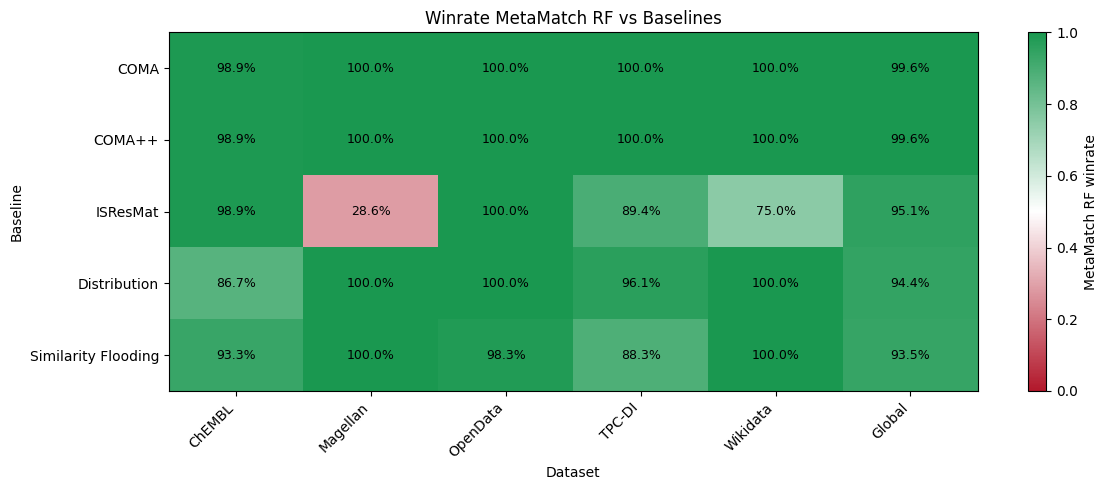


Saved:
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_pair_level.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_global_winrate.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_dataset_winrate.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_winrate_matrix.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/heatmap_metamatch_rf_vs_baselines_winrate.png

Global winrate:
             method  n_common_pairs  wins  losses  ties  winrate_total  winrate_no_ties  mean_metamatch_f1  mean_baseline_f1  mean_diff
               COMA           5

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

ROOT = Path("/Users/nahawandkired/Documents/metamatch/outputs")

OUT_DIR = ROOT / "final_consolidated_baselines_FULL" / "winrate_metamatch_rf_vs_baselines"
OUT_DIR.mkdir(parents=True, exist_ok=True)

METAMATCH_FILES = [
    ROOT / "exp_occidata/reports/meeting_baselines_vs_metamatch/metaspace_rf_61features_seed42/metaspace_rf_61features_seed42_ground_size_by_pair_mean.csv",
    ROOT / "exp_occidata/reports/meeting_baselines_vs_metamatch/metaspace_rf_61features_seed42/metaspace_rf_61features_seed42_ground_size_by_pair_fold.csv",
]

BASELINE_PAIR_FILES = [
    ROOT / "final_consolidated_baselines_FULL/final_all_results_pair_level.csv",
    ROOT / "final_consolidated_baselines_FULL/recomputed_missing_valentine_pair_level.csv",
]

PREFER_RECOMPUTED = {"Distribution", "ISResMat"}
KEEP_ORIGINAL_FOR = {"COMA", "COMA++", "Similarity Flooding"}

def find_existing(files):
    for f in files:
        if f.exists():
            return f
    raise FileNotFoundError("Aucun fichier trouvé.")

def normalize_method(m):
    mapping = {
        "LLMatch-llm": "LLMATCH",
        "LLMATCH": "LLMATCH",
        "SMUTF": "SMUTF",
        "Coma": "COMA",
        "COMA": "COMA",
        "Coma++": "COMA++",
        "COMA++": "COMA++",
        "SimilarityFlooding": "Similarity Flooding",
        "Similarity Flooding": "Similarity Flooding",
        "Distribution Based": "Distribution",
        "Distribution": "Distribution",
        "ISResMat": "ISResMat",
        "Cupid": "Cupid",
    }
    return mapping.get(str(m).strip(), str(m).strip())

def get_f1_col(df):
    candidates = [
        "f1_all_to_all",
        "All_F1Score",
        "F1",
        "mean_f1_pairs",
        "f1_all_to_all_mean",
        "f1_at_ground_size",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(df.columns.tolist())

def get_dataset_col(df):
    if "dataset" in df.columns:
        return "dataset"
    if "category" in df.columns:
        return "category"
    return None

def infer_dataset(pair_id):
    return str(pair_id).split("__")[0]

# ============================================================
# 1. METAMATCH RF
# ============================================================

meta_file = find_existing(METAMATCH_FILES)
meta = pd.read_csv(meta_file, low_memory=False)

print("MetaMatch file:", meta_file)
print("MetaMatch columns:", meta.columns.tolist())

if "pair_id" not in meta.columns:
    raise ValueError("MetaMatch doit contenir pair_id")

if "dataset" not in meta.columns:
    meta["dataset"] = meta["pair_id"].map(infer_dataset)

meta_f1_candidates = [
    "mean_f1_pairs",
    "f1_all_to_all_mean",
    "f1_at_ground_size_mean",
    "f1_at_ground_size",
    "f1_mean",
    "mean_f1",
    "f1",
    "F1",
    "All_F1Score",
    "mean",
]

meta_f1_col = None
for c in meta_f1_candidates:
    if c in meta.columns:
        meta_f1_col = c
        break

if meta_f1_col is None:
    numeric_cols = meta.select_dtypes(include=[np.number]).columns.tolist()
    print("Numeric columns:", numeric_cols)
    # Choix automatique : première colonne numérique non fold/seed/count
    bad_words = ["fold", "seed", "count", "n_", "runtime", "std"]
    candidates = [
        c for c in numeric_cols
        if not any(b in c.lower() for b in bad_words)
    ]
    if not candidates:
        raise ValueError("Impossible de détecter une colonne F1 MetaMatch.")
    meta_f1_col = candidates[0]

print("Using MetaMatch F1 column:", meta_f1_col)

meta_rf = meta[["pair_id", "dataset", meta_f1_col]].copy()
meta_rf.columns = ["pair_id", "dataset", "metamatch_rf_f1"]
meta_rf["metamatch_rf_f1"] = pd.to_numeric(meta_rf["metamatch_rf_f1"], errors="coerce")
meta_rf = meta_rf.dropna(subset=["metamatch_rf_f1"])
meta_rf = meta_rf.sort_values("metamatch_rf_f1", ascending=False).drop_duplicates("pair_id")

print("MetaMatch pairs:", meta_rf["pair_id"].nunique())

# ============================================================
# 2. BASELINES
# ============================================================

parts = []

for f in BASELINE_PAIR_FILES:
    if not f.exists():
        print("Missing:", f)
        continue

    d = pd.read_csv(f, low_memory=False)

    if "pair_id" not in d.columns:
        d["pair_id"] = (
            d["dataset"].astype(str)
            + "__"
            + d["source_table"].astype(str)
            + "__"
            + d["target_table"].astype(str)
        )

    if "dataset" not in d.columns:
        d["dataset"] = d["pair_id"].map(infer_dataset)

    f1_col = get_f1_col(d)

    tmp = d[["method", "pair_id", "dataset", f1_col]].copy()
    tmp.columns = ["method", "pair_id", "dataset", "baseline_f1"]
    tmp["method"] = tmp["method"].map(normalize_method)
    tmp["baseline_f1"] = pd.to_numeric(tmp["baseline_f1"], errors="coerce")
    tmp["source_file"] = str(f)

    parts.append(tmp)

baselines = pd.concat(parts, ignore_index=True).dropna(subset=["baseline_f1"])

def source_priority(row):
    m = row["method"]
    is_recomputed = "recomputed_missing_valentine_pair_level" in row["source_file"]

    if m in PREFER_RECOMPUTED:
        return 0 if is_recomputed else 1

    if m in KEEP_ORIGINAL_FOR:
        return 0 if not is_recomputed else 9

    return 0

baselines["priority"] = baselines.apply(source_priority, axis=1)

baselines_clean = (
    baselines.sort_values(
        ["method", "pair_id", "priority", "baseline_f1"],
        ascending=[True, True, True, False]
    )
    .drop_duplicates(["method", "pair_id"])
)

print("\nBaseline coverage:")
print(baselines_clean.groupby("method")["pair_id"].nunique().sort_values(ascending=False))

# ============================================================
# 3. MERGE + WINRATE
# ============================================================

merged = baselines_clean.merge(
    meta_rf,
    on="pair_id",
    how="inner",
    suffixes=("_baseline", "_meta")
)

merged["dataset"] = merged["dataset_baseline"].fillna(merged["dataset_meta"])
merged["diff"] = merged["metamatch_rf_f1"] - merged["baseline_f1"]

merged["result"] = np.where(
    merged["diff"] > 1e-12,
    "win",
    np.where(merged["diff"] < -1e-12, "loss", "tie")
)

def summarize(g):
    wins = (g["result"] == "win").sum()
    losses = (g["result"] == "loss").sum()
    ties = (g["result"] == "tie").sum()
    total = len(g)

    return pd.Series({
        "n_common_pairs": total,
        "wins": wins,
        "losses": losses,
        "ties": ties,
        "winrate_total": wins / total if total else np.nan,
        "winrate_no_ties": wins / (wins + losses) if wins + losses else np.nan,
        "mean_metamatch_f1": g["metamatch_rf_f1"].mean(),
        "mean_baseline_f1": g["baseline_f1"].mean(),
        "mean_diff": g["diff"].mean(),
    })

global_winrate = (
    merged.groupby("method")
    .apply(summarize)
    .reset_index()
    .sort_values("winrate_total", ascending=False)
)

dataset_winrate = (
    merged.groupby(["method", "dataset"])
    .apply(summarize)
    .reset_index()
)

matrix = dataset_winrate.pivot(
    index="method",
    columns="dataset",
    values="winrate_total"
)

matrix["Global"] = global_winrate.set_index("method")["winrate_total"]
matrix = matrix.sort_values("Global", ascending=False)

# ============================================================
# 4. SAVE
# ============================================================

pair_out = OUT_DIR / "metamatch_rf_vs_baselines_pair_level.csv"
global_out = OUT_DIR / "metamatch_rf_vs_baselines_global_winrate.csv"
dataset_out = OUT_DIR / "metamatch_rf_vs_baselines_dataset_winrate.csv"
matrix_out = OUT_DIR / "metamatch_rf_vs_baselines_winrate_matrix.csv"
heatmap_out = OUT_DIR / "heatmap_metamatch_rf_vs_baselines_winrate.png"

merged.to_csv(pair_out, index=False)
global_winrate.to_csv(global_out, index=False)
dataset_winrate.to_csv(dataset_out, index=False)
matrix.to_csv(matrix_out)

# ============================================================
# 5. HEATMAP
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#b2182b", "#ffffff", "#1a9850"]
)

norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(matrix))))
im = ax.imshow(matrix.values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(matrix.shape[1]))
ax.set_yticks(np.arange(matrix.shape[0]))
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val*100:.1f}%", ha="center", va="center", fontsize=9)

ax.set_title("Winrate MetaMatch RF vs Baselines")
ax.set_xlabel("Dataset")
ax.set_ylabel("Baseline")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("MetaMatch RF winrate")

plt.tight_layout()
plt.savefig(heatmap_out, dpi=300)
plt.show()

print("\nSaved:")
print(pair_out)
print(global_out)
print(dataset_out)
print(matrix_out)
print(heatmap_out)

print("\nGlobal winrate:")
print(global_winrate.to_string(index=False))

MetaMatch file: /Users/nahawandkired/Documents/metamatch/outputs/exp_occidata/reports/meeting_baselines_vs_metamatch/metaspace_rf_61features_seed42/metaspace_rf_61features_seed42_ground_size_by_pair_mean.csv
MetaMatch columns: ['method', 'pair_id', 'f1_ground_size', 'precision_ground_size', 'recall_ground_size', 'n_appearances']
Using MetaMatch F1 column: f1_ground_size
MetaMatch pairs: 551
                                               pair_id   dataset  \
547            Wikidata__Musicians__Musicians_joinable  Wikidata   
0            ChEMBL__Joinable__assays_both_50_1_ac1_ev    ChEMBL   
1            ChEMBL__Joinable__assays_both_50_1_ac2_ev    ChEMBL   
2            ChEMBL__Joinable__assays_both_50_1_ac3_ev    ChEMBL   
530  TPC-DI__View-Unionable__prospect_both_0_50_ac4_ev    TPC-DI   

     metamatch_rf_f1  
547              1.0  
0                1.0  
1                1.0  
2                1.0  
530              1.0  

Loaded: /Users/nahawandkired/Documents/metamatch/outputs/f

/var/folders/0d/rr_6cb2x1jqdcpbsffvvpkyr0000gn/T/ipykernel_95040/2877096781.py:326: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.groupby("method")
/var/folders/0d/rr_6cb2x1jqdcpbsffvvpkyr0000gn/T/ipykernel_95040/2877096781.py:343: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged.groupby(["method", "dataset"])


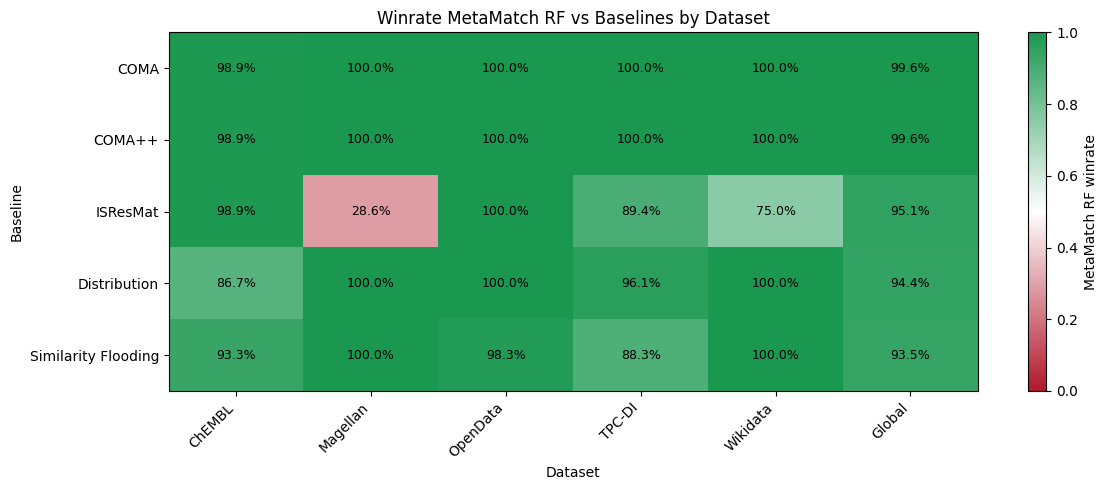


Saved:
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_pair_level.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_global_winrate.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_dataset_winrate.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/metamatch_rf_vs_baselines_winrate_matrix.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/missing_pairs_vs_metamatch.csv
/Users/nahawandkired/Documents/metamatch/outputs/final_consolidated_baselines_FULL/winrate_metamatch_rf_vs_baselines/heatmap_metamatch_rf_vs_baselines_winrate.png


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# ============================================================
# CONFIG
# ============================================================

ROOT = Path("/Users/nahawandkired/Documents/metamatch/outputs")

OUT_DIR = ROOT / "final_consolidated_baselines_FULL" / "winrate_metamatch_rf_vs_baselines"
OUT_DIR.mkdir(parents=True, exist_ok=True)

METAMATCH_FILES = [
    ROOT / "exp_occidata/reports/meeting_baselines_vs_metamatch/metaspace_rf_61features_seed42/metaspace_rf_61features_seed42_ground_size_by_pair_mean.csv",
    ROOT / "exp_occidata/reports/meeting_baselines_vs_metamatch/metaspace_rf_61features_seed42/metaspace_rf_61features_seed42_ground_size_by_pair_fold.csv",
]

BASELINE_PAIR_FILES = [
    ROOT / "final_consolidated_baselines_FULL/final_all_results_pair_level.csv",
    ROOT / "final_consolidated_baselines_FULL/recomputed_missing_valentine_pair_level.csv",
]

PREFER_RECOMPUTED = {"Distribution", "ISResMat"}
KEEP_ORIGINAL_FOR = {"COMA", "COMA++", "Similarity Flooding"}

# ============================================================
# HELPERS
# ============================================================

def find_existing(files):
    for f in files:
        if f.exists():
            return f
    raise FileNotFoundError("Aucun fichier trouvé parmi:\n" + "\n".join(map(str, files)))

def normalize_method(m):
    m = str(m).strip()
    mapping = {
        "LLMATCH": "LLMATCH",
        "LLMatch-llm": "LLMATCH",
        "LLMATCH_CUPID": "LLMATCH",
        "SMUTF": "SMUTF",
        "Coma": "COMA",
        "coma": "COMA",
        "COMA": "COMA",
        "Coma++": "COMA++",
        "coma_pp": "COMA++",
        "COMA++": "COMA++",
        "SimilarityFlooding": "Similarity Flooding",
        "similarity_flooding": "Similarity Flooding",
        "Similarity Flooding": "Similarity Flooding",
        "Distribution": "Distribution",
        "distribution_based": "Distribution",
        "Distribution Based": "Distribution",
        "ISResMat": "ISResMat",
        "Cupid": "Cupid",
        "Magneto": "Magneto",
        "MagnetoFT": "MagnetoFT",
        "MagnetoGPT": "MagnetoGPT",
        "MagnetoFTGPT": "MagnetoFTGPT",
    }
    return mapping.get(m, m)

def infer_dataset_from_pair_id(pair_id):
    return str(pair_id).split("__")[0]

def get_f1_col(df):
    candidates = [
        "f1_all_to_all",
        "All_F1Score",
        "F1",
        "mean_f1_pairs",
        "f1_all_to_all_mean",
        "f1_at_ground_size",
        "f1_ground_size",
        "f1_at_ground_size_mean",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Aucune colonne F1 trouvée. Colonnes: {df.columns.tolist()}")

def get_dataset_col_or_create(df):
    if "dataset" in df.columns:
        return "dataset"
    if "category" in df.columns:
        return "category"
    if "pair_id" in df.columns:
        df["dataset"] = df["pair_id"].map(infer_dataset_from_pair_id)
        return "dataset"
    raise ValueError("Aucune colonne dataset/category/pair_id trouvée.")

def source_priority(row):
    m = row["method"]
    src = row["source_file"]
    is_recomputed = "recomputed_missing_valentine_pair_level" in src

    # Recalcul validé uniquement pour Distribution et ISResMat
    if m in PREFER_RECOMPUTED:
        return 0 if is_recomputed else 1

    # Pour COMA / COMA++ / Similarity Flooding, on garde Valentine original
    if m in KEEP_ORIGINAL_FOR:
        return 0 if not is_recomputed else 9

    return 0

# ============================================================
# 1. LOAD METAMATCH RF
# ============================================================

meta_file = find_existing(METAMATCH_FILES)
meta = pd.read_csv(meta_file, low_memory=False)

print("MetaMatch file:", meta_file)
print("MetaMatch columns:", meta.columns.tolist())

if "pair_id" not in meta.columns:
    raise ValueError("MetaMatch doit contenir une colonne pair_id.")

if "dataset" not in meta.columns and "category" not in meta.columns:
    meta["dataset"] = meta["pair_id"].map(infer_dataset_from_pair_id)

meta_dataset_col = get_dataset_col_or_create(meta)

meta_f1_candidates = [
    "f1_ground_size",
    "f1_at_ground_size_mean",
    "mean_f1_pairs",
    "f1_all_to_all_mean",
    "f1_at_ground_size",
    "mean_f1",
    "f1_mean",
    "f1",
    "F1",
    "All_F1Score",
]

meta_f1_col = None
for c in meta_f1_candidates:
    if c in meta.columns:
        meta_f1_col = c
        break

if meta_f1_col is None:
    numeric_cols = meta.select_dtypes(include=[np.number]).columns.tolist()
    print("Numeric columns:", numeric_cols)
    raise ValueError("Impossible de détecter la colonne F1 MetaMatch.")

print("Using MetaMatch F1 column:", meta_f1_col)

meta_rf = meta[["pair_id", meta_dataset_col, meta_f1_col]].copy()
meta_rf.columns = ["pair_id", "dataset", "metamatch_rf_f1"]
meta_rf["metamatch_rf_f1"] = pd.to_numeric(meta_rf["metamatch_rf_f1"], errors="coerce")
meta_rf = meta_rf.dropna(subset=["pair_id", "metamatch_rf_f1"])
meta_rf = (
    meta_rf.sort_values("metamatch_rf_f1", ascending=False)
           .drop_duplicates("pair_id", keep="first")
)

REF_PAIRS = set(meta_rf["pair_id"].unique())

print("MetaMatch pairs:", len(REF_PAIRS))
print(meta_rf.head())

# ============================================================
# 2. LOAD BASELINES
# ============================================================

baseline_parts = []

for f in BASELINE_PAIR_FILES:
    if not f.exists():
        print("Missing baseline file:", f)
        continue

    d = pd.read_csv(f, low_memory=False)

    print("\nLoaded:", f)
    print("rows:", len(d))
    print("cols:", d.columns.tolist())

    if "method" not in d.columns:
        raise ValueError(f"Pas de colonne method dans {f}")

    if "pair_id" not in d.columns:
        if {"dataset", "source_table", "target_table"}.issubset(d.columns):
            d["pair_id"] = (
                d["dataset"].astype(str)
                + "__"
                + d["source_table"].astype(str)
                + "__"
                + d["target_table"].astype(str)
            )
        else:
            raise ValueError(f"Pas de pair_id dans {f}")

    dataset_col = get_dataset_col_or_create(d)
    f1_col = get_f1_col(d)

    tmp = d[["method", "pair_id", dataset_col, f1_col]].copy()
    tmp.columns = ["method", "pair_id", "dataset", "baseline_f1"]
    tmp["method"] = tmp["method"].map(normalize_method)
    tmp["baseline_f1"] = pd.to_numeric(tmp["baseline_f1"], errors="coerce")
    tmp["source_file"] = str(f)

    baseline_parts.append(tmp)

baselines = pd.concat(baseline_parts, ignore_index=True)
baselines = baselines.dropna(subset=["pair_id", "baseline_f1"])

print("\nRaw baseline coverage BEFORE filtering:")
print(
    baselines.groupby("method")["pair_id"]
    .nunique()
    .sort_values(ascending=False)
    .to_string()
)

# ============================================================
# 2bis. FILTER STRICTLY ON METAMATCH 551 PAIRS
# ============================================================

baselines = baselines[baselines["pair_id"].isin(REF_PAIRS)].copy()

print("\nBaseline coverage AFTER filtering on MetaMatch 551 pairs:")
print(
    baselines.groupby("method")["pair_id"]
    .nunique()
    .sort_values(ascending=False)
    .to_string()
)

# ============================================================
# 3. DEDUPLICATE WITH SOURCE PRIORITY
# ============================================================

baselines["priority"] = baselines.apply(source_priority, axis=1)

baselines_clean = (
    baselines.sort_values(
        ["method", "pair_id", "priority", "baseline_f1"],
        ascending=[True, True, True, False]
    )
    .drop_duplicates(["method", "pair_id"], keep="first")
)

print("\nBaseline coverage CLEAN:")
print(
    baselines_clean.groupby("method")["pair_id"]
    .nunique()
    .sort_values(ascending=False)
    .to_string()
)

missing_report = []

for m, g in baselines_clean.groupby("method"):
    have = set(g["pair_id"])
    missing_report.append({
        "method": m,
        "n_pairs": len(have),
        "n_missing_vs_metamatch": len(REF_PAIRS - have),
    })

missing_report = pd.DataFrame(missing_report).sort_values("n_missing_vs_metamatch")

print("\nMissing report vs MetaMatch:")
print(missing_report.to_string(index=False))

missing_out = OUT_DIR / "missing_pairs_vs_metamatch.csv"
missing_report.to_csv(missing_out, index=False)

# ============================================================
# 4. MERGE METAMATCH VS BASELINES
# ============================================================

merged = baselines_clean.merge(
    meta_rf,
    on="pair_id",
    how="inner",
    suffixes=("_baseline", "_meta")
)

merged["dataset"] = merged["dataset_baseline"].fillna(merged["dataset_meta"])

merged["diff"] = merged["metamatch_rf_f1"] - merged["baseline_f1"]
merged["result"] = np.where(
    merged["diff"] > 1e-12,
    "win",
    np.where(merged["diff"] < -1e-12, "loss", "tie")
)

pair_out = OUT_DIR / "metamatch_rf_vs_baselines_pair_level.csv"
merged.to_csv(pair_out, index=False)

print("\nSaved pair-level:", pair_out)
print("Merged rows:", len(merged))

# ============================================================
# 5. WINRATE GLOBAL
# ============================================================

def summarize_winrate(g):
    wins = (g["result"] == "win").sum()
    losses = (g["result"] == "loss").sum()
    ties = (g["result"] == "tie").sum()
    total = len(g)

    return pd.Series({
        "n_common_pairs": total,
        "wins": wins,
        "losses": losses,
        "ties": ties,
        "winrate_total": wins / total if total else np.nan,
        "winrate_no_ties": wins / (wins + losses) if (wins + losses) else np.nan,
        "mean_metamatch_f1": g["metamatch_rf_f1"].mean(),
        "mean_baseline_f1": g["baseline_f1"].mean(),
        "mean_diff": g["diff"].mean(),
    })

global_winrate = (
    merged.groupby("method")
          .apply(summarize_winrate)
          .reset_index()
          .sort_values("winrate_total", ascending=False)
)

global_out = OUT_DIR / "metamatch_rf_vs_baselines_global_winrate.csv"
global_winrate.to_csv(global_out, index=False)

print("\nGlobal winrate:")
print(global_winrate.to_string(index=False))

# ============================================================
# 6. WINRATE BY DATASET
# ============================================================

dataset_winrate = (
    merged.groupby(["method", "dataset"])
          .apply(summarize_winrate)
          .reset_index()
)

dataset_out = OUT_DIR / "metamatch_rf_vs_baselines_dataset_winrate.csv"
dataset_winrate.to_csv(dataset_out, index=False)

matrix = dataset_winrate.pivot(
    index="method",
    columns="dataset",
    values="winrate_total"
)

global_series = global_winrate.set_index("method")["winrate_total"]
matrix["Global"] = global_series
matrix = matrix.sort_values("Global", ascending=False)

matrix_out = OUT_DIR / "metamatch_rf_vs_baselines_winrate_matrix.csv"
matrix.to_csv(matrix_out)

print("\nWinrate matrix:")
print(matrix.to_string())

# ============================================================
# 7. HEATMAP GREEN-WHITE-RED
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#b2182b", "#ffffff", "#1a9850"]
)
norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(matrix))))

im = ax.imshow(matrix.values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(matrix.shape[1]))
ax.set_yticks(np.arange(matrix.shape[0]))

ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val*100:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

ax.set_title("Winrate MetaMatch RF vs Baselines by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Baseline")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("MetaMatch RF winrate")

plt.tight_layout()

heatmap_out = OUT_DIR / "heatmap_metamatch_rf_vs_baselines_winrate.png"
plt.savefig(heatmap_out, dpi=300)
plt.show()

print("\nSaved:")
print(pair_out)
print(global_out)
print(dataset_out)
print(matrix_out)
print(missing_out)
print(heatmap_out)